# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

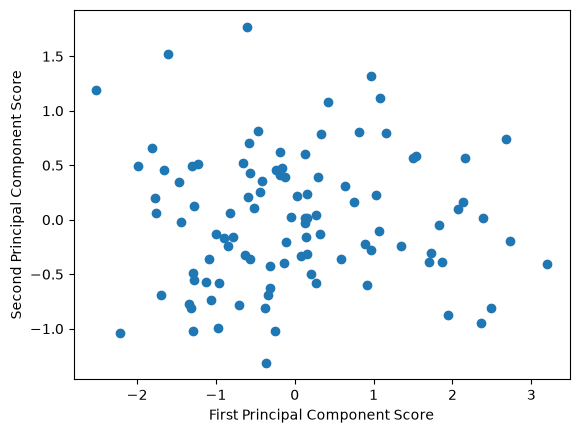

In [2]:
np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

Advantages: 
- It compresses 3 variables into 2 while keeping ~99% of the variance (80%+19%)
- It correctly isolates the one non-redundant piece of information (ser3's deviation) as its own axis — an outlier that isn't obvious from any single histogram.

Disadvantages: 
- The axes are abstract linear combinations, not directly interpretable without going back to the loadings
- It silently discards the ser1-vs-ser2 distinction (into PC3) since that information carries almost no variance
- It can't show you the actual functional relationships (the tight linear ser1-ser2 relationship, the looser ser1/ser2-ser3 relationship) that the pairplot makes immediately visual.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

## All Datasets

In [57]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

import warnings
warnings.filterwarnings('ignore')

In [58]:
pd.set_option('display.max_columns', 100)

## Dataset 1: Malware

### Setup

In [120]:
# Load and combine the datasets
files = [
    "malware_benign_06162017_1.csv",
    "malware_benign_06162017_2.csv",
    "malware_benign_06162017_3.csv",
    "malware_benign_06162017_4.csv",
    "malware_benign_06162017_5.csv",
    "malware_benign_06162017_6.csv",
    "malware_benign_06162017_7.csv",
    "malware_benign_06162017_8.csv",
    "malware_benign_06162017_9.csv",
    "malware_benign_06162017_10.csv",
    "malware_benign_06162017_11.csv",
    "malware_benign_06162017_12.csv",
    "malware_benign_06162017_13.csv",
    "malware_benign_06162017_14.csv",
    "malware_benign_06162017_15.csv",
    "ransomware_wannalocker_08212017_1.csv",
    "ransomware_wannalocker_08212017_2.csv",
    "ransomware_wannalocker_08212017_3.csv"
]

dfs = []
for f in files:
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

ransomware_df = pd.concat(dfs, ignore_index=True)
print(ransomware_df.shape)

(18231, 85)


In [121]:
# Print the dataset
ransomware_df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,0,1,0,0,0,0,1.0,403.642857,179.333333,571.875000,200,0,0,0,0,0,0,6,1076,8,4575,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16/06/2017 03:55:52,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16/06/2017 03:55:53,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,1,0,0,1,0,0,0,1.0,31.000000,31.000000,0.000000,32,0,0,0,0,0,0,1,31,1,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16/06/2017 03:55:58,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,0,1,0,0,0,0,1.0,124.615385,218.833333,43.857143,200,0,0,0,0,0,0,6,1313,7,307,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [122]:
# Normalize the Label column
print("Before:", ransomware_df['Label'].unique())

ransomware_df['Label'] = np.where(ransomware_df['Label'].str.strip().str.upper() == 'BENIGN', 0, 1)

print("After:", ransomware_df['Label'].unique())
ransomware_df['Label'].value_counts()

Before: <StringArray>
['BENIGN', 'RANSOMWARE_WANNALOCKER']
Length: 2, dtype: str
After: [0 1]


Label
1    10161
0     8070
Name: count, dtype: int64

In [123]:
# Drop duplicate rows
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 0 duplicate rows -> 18231 rows remaining


In [124]:
# Drop null & NaN values
before = len(ransomware_df)
ransomware_df = ransomware_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(ransomware_df)} rows with null/NaN values -> {len(ransomware_df)} rows remaining")

Dropped 0 rows with null/NaN values -> 18231 rows remaining


In [125]:
# Drop negative values
before = len(ransomware_df)
numeric_cols = ransomware_df.select_dtypes(include=[np.number]).columns

# Init_Win_bytes_backward uses -1 as a sentinel meaning "no backward-direction"
# "window observed" (not invalid data), so it is excluded from the negative-value check.
negative_check_cols = numeric_cols.drop('Init_Win_bytes_backward')

negative_mask = (ransomware_df[negative_check_cols] < 0).any(axis=1)
ransomware_df = ransomware_df[~negative_mask]
print(f"Dropped {before - len(ransomware_df)} rows containing negative values (excluding Init_Win_bytes_backward) -> {len(ransomware_df)} rows remaining")

Dropped 4068 rows containing negative values (excluding Init_Win_bytes_backward) -> 14163 rows remaining


In [126]:
# Drop non-numeric columns
non_numeric_cols = ransomware_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

ransomware_df = ransomware_df.drop(columns=non_numeric_cols)
print(ransomware_df.shape)

Dropping non-numeric columns: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
(14163, 81)


In [127]:
# Drop perfectly correlated columns
corr_matrix = ransomware_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

ransomware_df = ransomware_df.drop(columns=perfectly_correlated)
print(ransomware_df.shape)

Dropping 8 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(14163, 73)


In [128]:
# Drop duplicate rows (post feature engineering)
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 0 duplicate rows -> 14163 rows remaining


In [129]:
# Print cleaned DataFrame
ransomware_df.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,51023,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,1,0,0,0,0,1.0,403.642857,0,0,0,0,0,0,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,51023,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,34259,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,55509,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,0,0,1,0,0,0,1.0,31.000000,0,0,0,0,0,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,44852,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,1,0,0,0,0,1.0,124.615385,0,0,0,0,0,0,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [130]:
# Sanity check
print("Any nulls left:", ransomware_df.isnull().values.any())
print("Any negatives left:", (ransomware_df < 0).values.any())
print("Any duplicate rows left:", ransomware_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in ransomware_df.dtypes))
print("\nFinal shape:", ransomware_df.shape)
print("\nLabel counts:")
print(ransomware_df['Label'].value_counts())

Any nulls left: False
Any negatives left: True
Any duplicate rows left: False
All columns numeric: True

Final shape: (14163, 73)

Label counts:
Label
1    7865
0    6298
Name: count, dtype: int64


In [131]:
# Export cleaned data to CSV
ransomware_df.to_csv("malware_combined_clean.csv", index=False)
print("Saved malware_combined_clean.csv")

Saved malware_combined_clean.csv


### Heatmaps

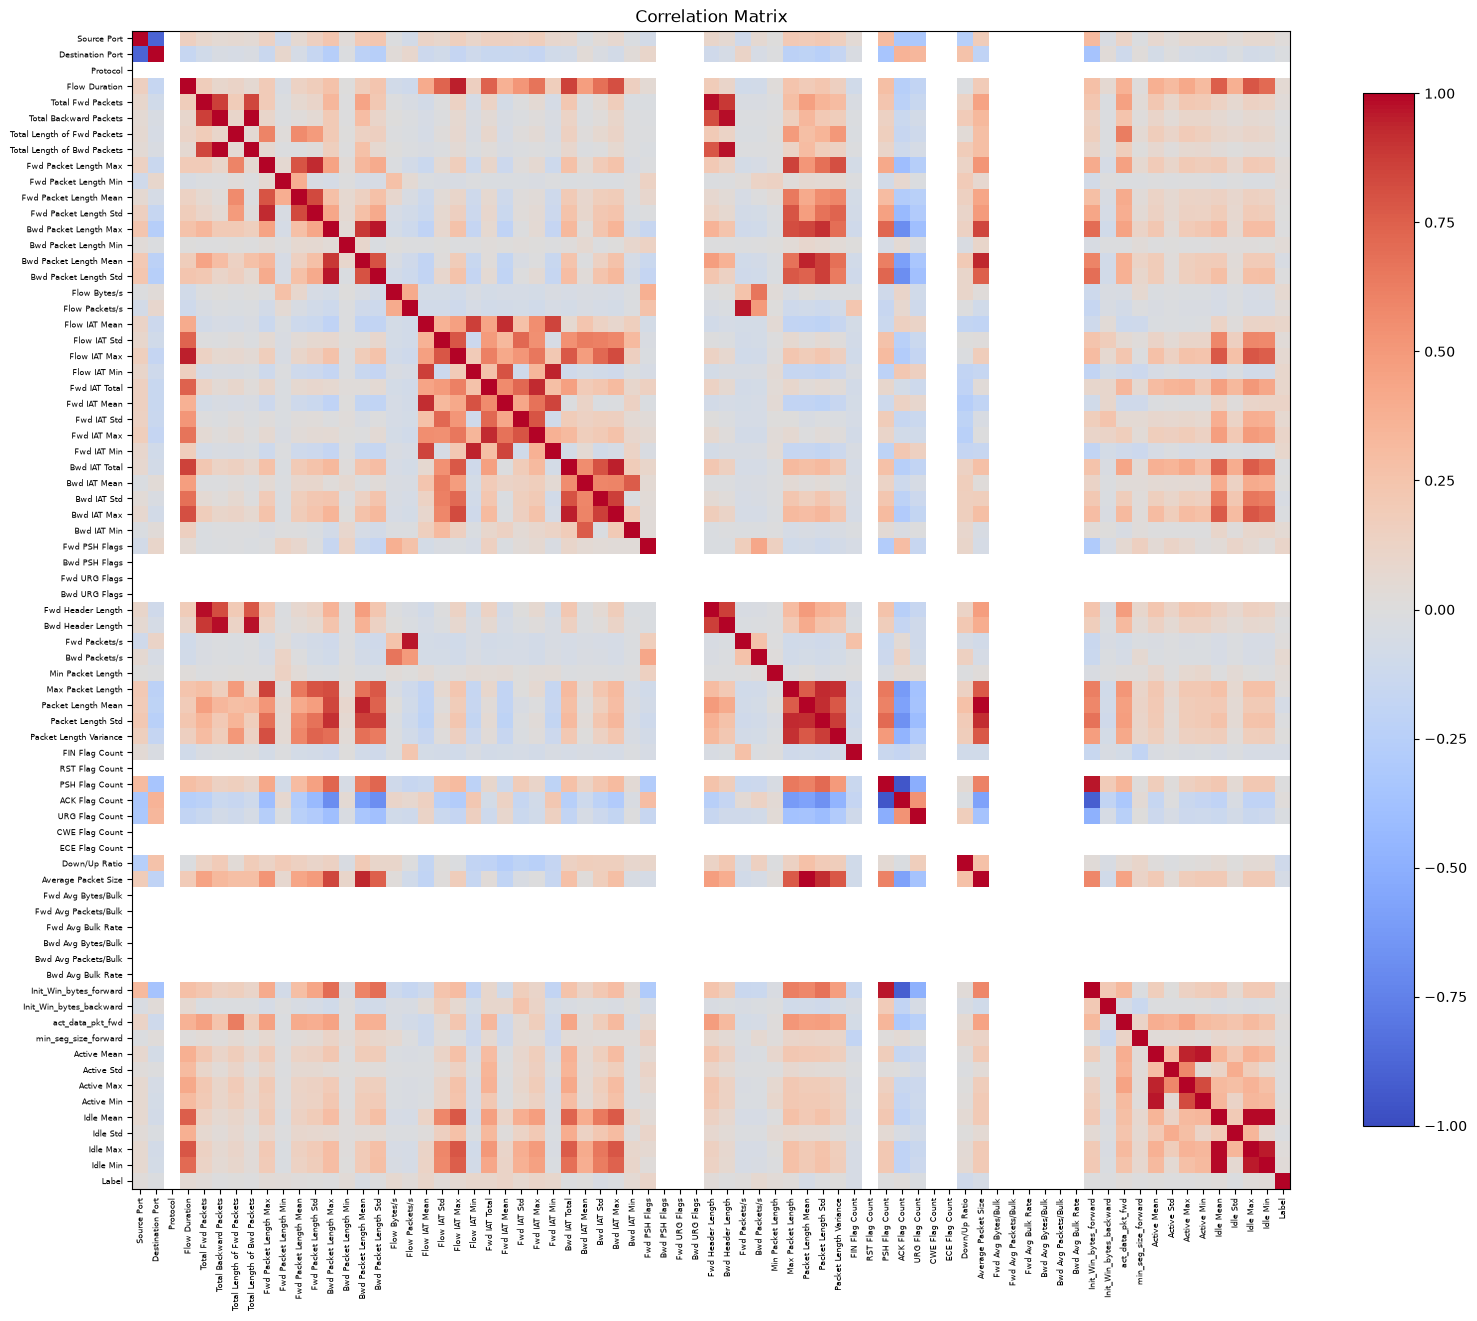

In [132]:
# Draw heatmaps

# Correlation
corr = ransomware_df.corr()

# Plot
fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticklabels(corr.columns, fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

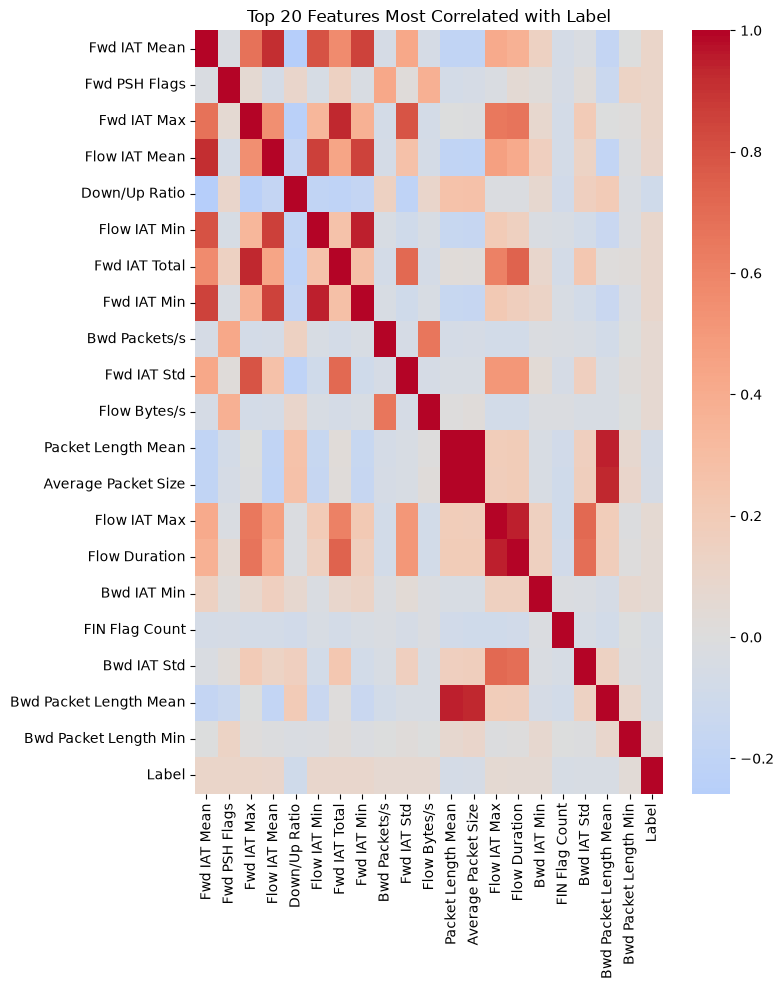

Fwd IAT Mean              0.109430
Fwd PSH Flags             0.108002
Fwd IAT Max               0.106388
Flow IAT Mean             0.096836
Down/Up Ratio            -0.096652
Flow IAT Min              0.092235
Fwd IAT Total             0.088831
Fwd IAT Min               0.088140
Bwd Packets/s             0.069577
Fwd IAT Std               0.066861
Flow Bytes/s              0.066189
Packet Length Mean       -0.061692
Average Packet Size      -0.058752
Flow IAT Max              0.057343
Flow Duration             0.053657
Bwd IAT Min               0.051168
FIN Flag Count           -0.049753
Bwd IAT Std              -0.046510
Bwd Packet Length Mean   -0.041691
Bwd Packet Length Min     0.036268
Name: Label, dtype: float64

In [133]:
# More readable: top features most correlated with Label
label_corr = corr['Label'].drop('Label').sort_values(key=lambda s: s.abs(), ascending=False)
top_n = 20
top_features = label_corr.head(top_n).index.tolist()

plt.figure(figsize=(8, 10))
sns.heatmap(ransomware_df[top_features + ['Label']].corr(), cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True)
plt.title(f"Top {top_n} Features Most Correlated with Label")
plt.tight_layout()
plt.show()

label_corr.head(top_n)

### Principal Component Analysis (PCA)

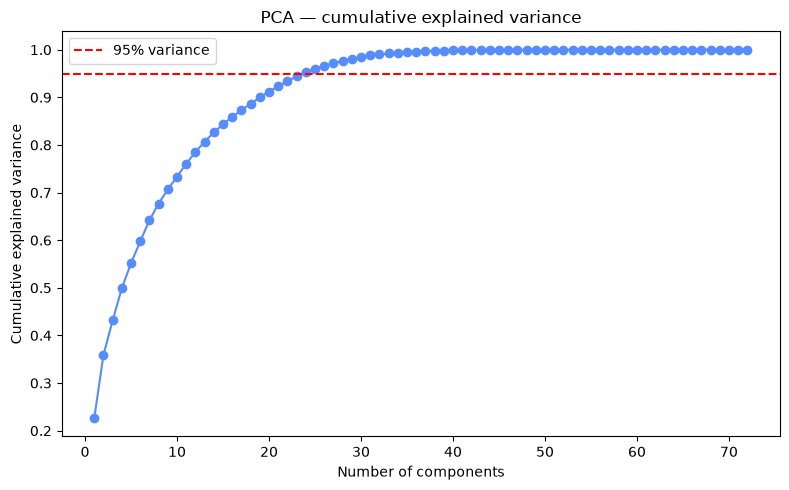

Components needed to explain 95% variance: 24 / 72


In [134]:
# Principal Component Analysis
X = ransomware_df.drop(columns=['Label'])
y = ransomware_df['Label']

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cumulative) + 1), cumulative, marker='o')
ax.axhline(0.95, color='red', linestyle='--', label='95% variance')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — cumulative explained variance')
ax.legend()
plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95) + 1)
print(f"Components needed to explain 95% variance: {n_components_95} / {X.shape[1]}")

### Bubbleplots

In [135]:
# Draw bubbleplots

# Setup: Using the first 3 principal components as plot axes (PC1/PC2/PC3), with bubble size mapped to a chosen raw feature and color mapped to `Label`.
pcs = pca.transform(X_scaled)
pc_df = pd.DataFrame(pcs[:, :3], columns=['PC1', 'PC2', 'PC3'], index=X.index)

def scaled_size(series, low=20, high=800):
    s = (series - series.min()) / (series.max() - series.min())
    return s * (high - low) + low

label_colors = y.map({0: 'tab:blue', 1: 'tab:red'})
label_names = {0: 'BENIGN', 1: 'RANSOMWARE_WANNALOCKER'}

In [136]:
# Bubbleplot function
def bubble_plot(x_col, y_col, size_col, title, filename):
    fig, ax = plt.subplots(figsize=(9, 7))
    sizes = scaled_size(X[size_col])
    for lbl, color in [(0, 'tab:blue'), (1, 'tab:red')]:
        mask = (y == lbl)
        ax.scatter(pc_df.loc[mask, x_col], pc_df.loc[mask, y_col],
                   s=sizes[mask], c=color, alpha=0.5, edgecolors='k', linewidths=0.3,
                   label=label_names[lbl])
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{title}\n(bubble size = {size_col})")
    ax.legend(title='Label', markerscale=0.5)
    plt.tight_layout()
    plt.show()

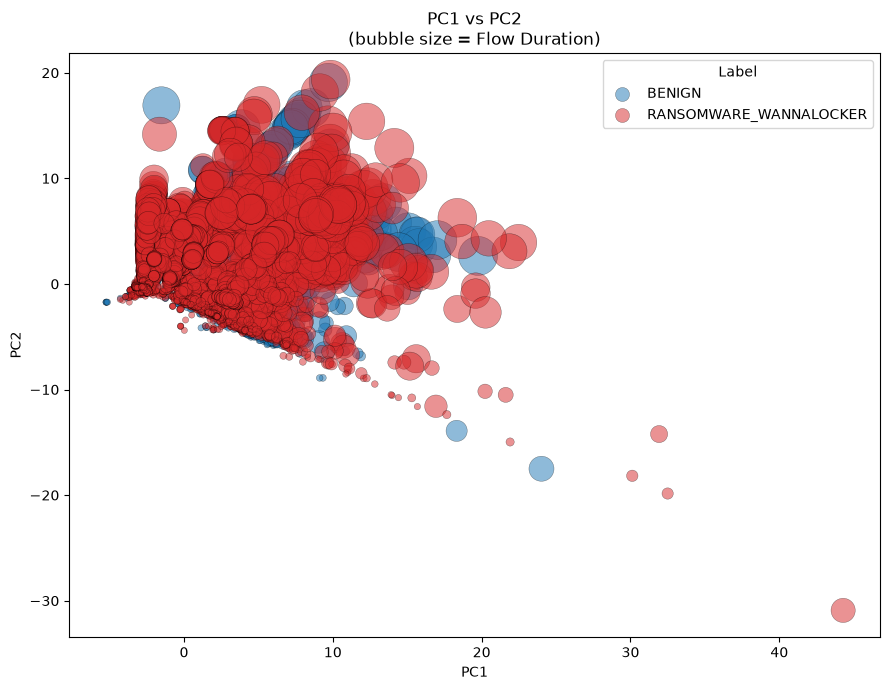

In [137]:
# Bubbleplot for Flow Duration
bubble_plot('PC1', 'PC2', 'Flow Duration', 'PC1 vs PC2', 'bubble_pc1_pc2_flowduration.png')

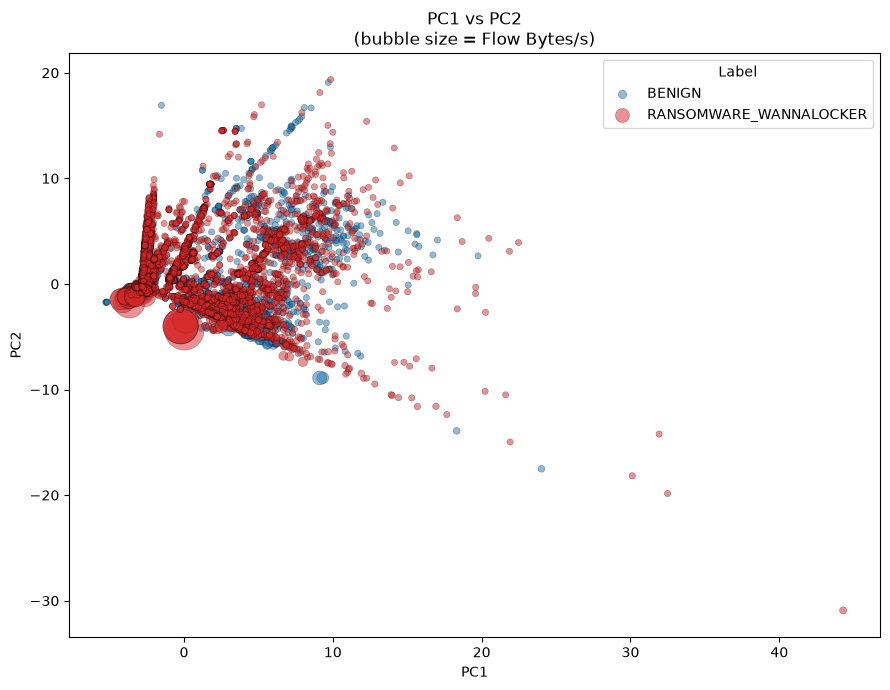

In [138]:
# Bubbleplot for Flow Bytes/s
bubble_plot('PC1', 'PC2', 'Flow Bytes/s', 'PC1 vs PC2', 'bubble_pc1_pc2_flowbytes.png')

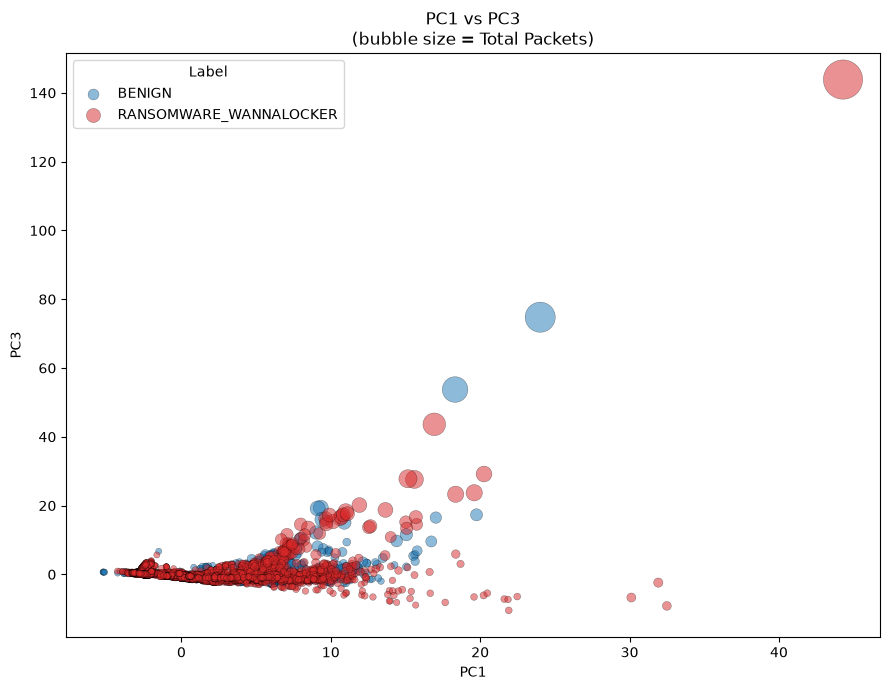

In [139]:
# Bubbleplot for Total Packets
X['Total Packets'] = X['Total Fwd Packets'] + X['Total Backward Packets']
bubble_plot('PC1', 'PC3', 'Total Packets', 'PC1 vs PC3', 'bubble_pc1_pc3_totalpackets.png')

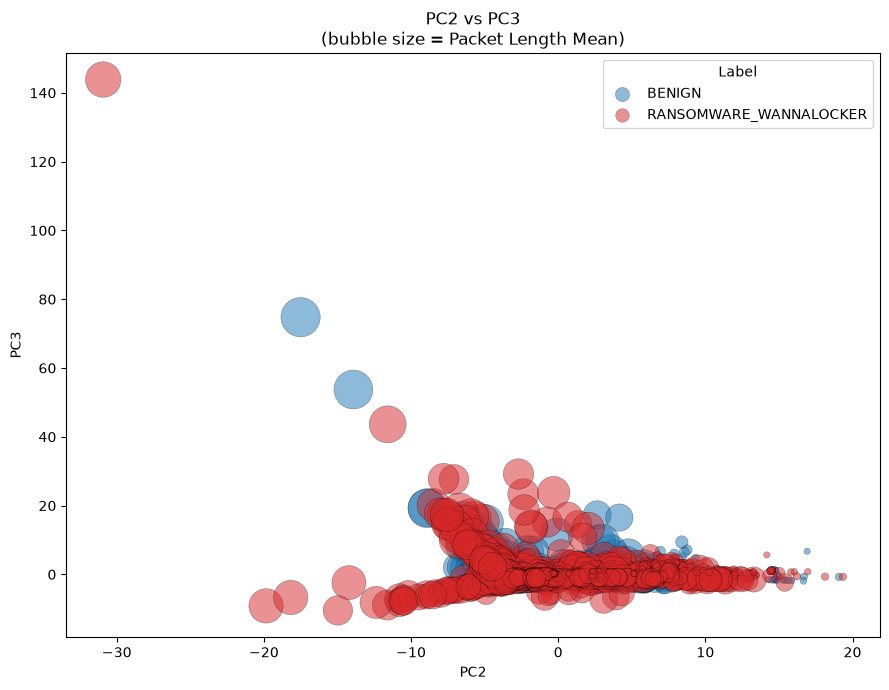

In [140]:
# Bubbleplot for Packet Length Mean
bubble_plot('PC2', 'PC3', 'Packet Length Mean', 'PC2 vs PC3', 'bubble_pc2_pc3_packetlen.png')

### Regression Analysis

In [141]:
# Regression

# Training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (11330, 73) Test shape: (2833, 73)


#### Linear Regression

In [142]:
# Linear Regression Analysis

# Calculate teh R^2 and RMSE
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)

print(f"R^2: {r2_score(y_test, y_pred_lin):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_lin) ** 0.5:.4f}")

# Accuracy if we threshold the continuous output at 0.5 to force a class decision
y_pred_lin_class = (y_pred_lin >= 0.5).astype(int)
print(f"Accuracy (0.5 threshold on linear output): {accuracy_score(y_test, y_pred_lin_class):.4f}")

R^2: 0.0688
RMSE: 0.4795
Accuracy (0.5 threshold on linear output): 0.5941


In [143]:
# Create Coefficient DataFrame & print
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lin_reg.coef_
}).sort_values('coefficient', key=abs, ascending=False)

coef_df.head(15)

,feature,coefficient
42,Packet Length Mean,-1.285722
53,Average Packet Size,0.737444
19,Flow IAT Std,-0.441855
18,Flow IAT Mean,0.390016
71,Idle Min,0.381534
21,Flow IAT Min,-0.378717
68,Idle Mean,-0.312842
14,Bwd Packet Length Mean,0.301666
20,Flow IAT Max,0.235641
43,Packet Length Std,0.232118


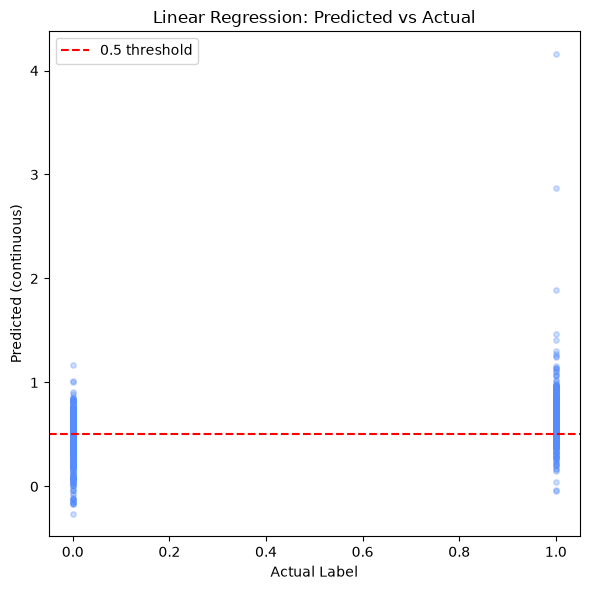

In [144]:
# Plot the Regression
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_lin, alpha=0.3, s=15)
ax.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
ax.set_xlabel('Actual Label')
ax.set_ylabel('Predicted (continuous)')
ax.set_title('Linear Regression: Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.show()

#### Logistic Regression

In [145]:
# Logistic Regression

# Setup
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_log):.4f}")
print()
print(classification_report(y_test, y_pred_log, target_names=['BENIGN', 'RANSOMWARE_WANNALOCKER']))

Accuracy: 0.5930
ROC-AUC: 0.6555

                        precision    recall  f1-score   support

                BENIGN       0.55      0.44      0.49      1260
RANSOMWARE_WANNALOCKER       0.61      0.72      0.66      1573

              accuracy                           0.59      2833
             macro avg       0.58      0.58      0.58      2833
          weighted avg       0.59      0.59      0.58      2833



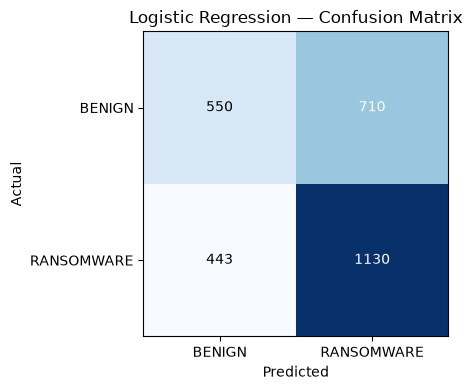

In [146]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['BENIGN', 'RANSOMWARE'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['BENIGN', 'RANSOMWARE'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

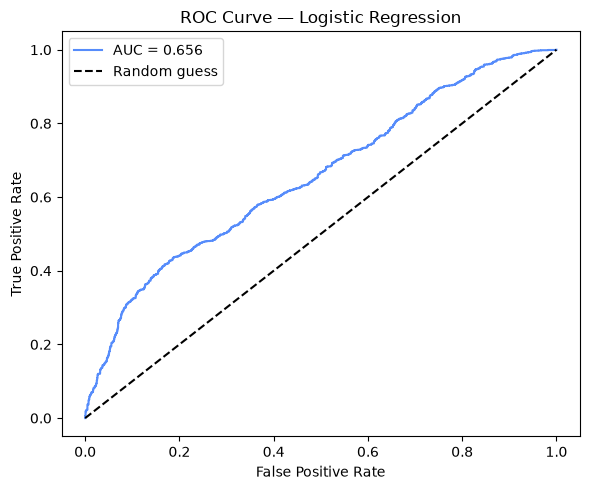

In [147]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_log)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba_log):.3f}")
ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.tight_layout()
plt.show()

## Dataset 2: Intrusion

### Setup

In [27]:
# Load the dataset

# Load and combine the datasets
files = [
    "network_traffic_1.csv",
    "network_traffic_2.csv",
    "network_traffic_3.csv",
    "network_traffic_4.csv",
    "network_traffic_5.csv",
    "network_traffic_6.csv",
    "network_traffic_7.csv",
    "network_traffic_8.csv"
]

# First read in as string to accommodate special character in Label column
dfs = []
for f in files:
    df = pd.read_csv(f, encoding="latin1", dtype=str)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

intrusion_df = pd.concat(dfs, ignore_index=True)

# Convert numeric columns to numbers
numeric_candidates = [c for c in intrusion_df.columns if c != 'Label']
intrusion_df[numeric_candidates] = intrusion_df[numeric_candidates].apply(pd.to_numeric, errors='coerce')

# Infinity parses to np.inf rather than NaN — if you want those treat as missing/dropped like NaN
intrusion_df[numeric_candidates] = intrusion_df[numeric_candidates].replace([np.inf, -np.inf], np.nan)

print(intrusion_df.shape)

(2830743, 79)


In [28]:
# Print the dataset
intrusion_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [29]:
# Normalize the Label column

# Where 0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk', 5: 'DoS Slowhttptest',
# 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'Heartbleed', 9: 'Infiltration', 10: 'PortScan', 11: 'SSH-Patator',
# 12: 'Web Attack - Brute Force', 13: 'Web Attack - Sql Injection', 14: 'Web Attack - XSS'
intrusion_df["Label"] = (
    intrusion_df["Label"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"Web Attack.*Brute Force", "Web Attack - Brute Force", regex=True)
    .str.replace(r"Web Attack.*Sql Injection", "Web Attack - Sql Injection", regex=True)
    .str.replace(r"Web Attack.*XSS", "Web Attack - XSS", regex=True)
)

# Build mapping from all unique label strings to integers
classes = sorted(intrusion_df["Label"].unique())
label_to_int = {label: i for i, label in enumerate(classes)}

with np.printoptions(threshold=np.inf):
    print("Before:", intrusion_df["Label"].astype("string").unique())

    intrusion_df["Label"] = intrusion_df["Label"].map(label_to_int)

    print("After:", intrusion_df["Label"].unique())

print(intrusion_df["Label"].value_counts())

Before: <StringArray>
[                    'BENIGN',                       'DDoS',
                   'PortScan',                        'Bot',
               'Infiltration',   'Web Attack - Brute Force',
           'Web Attack - XSS', 'Web Attack - Sql Injection',
                'FTP-Patator',                'SSH-Patator',
              'DoS slowloris',           'DoS Slowhttptest',
                   'DoS Hulk',              'DoS GoldenEye',
                 'Heartbleed']
Length: 15, dtype: string
After: [ 0  2 10  1  9 12 14 13  7 11  6  5  4  3  8]
Label
0     2273097
4      231073
10     158930
2      128027
3       10293
7        7938
11       5897
6        5796
5        5499
1        1966
12       1507
14        652
9          36
13         21
8          11
Name: count, dtype: int64


In [30]:
# Drop duplicate rows
before = len(intrusion_df)
intrusion_df = intrusion_df.drop_duplicates()
print(f"Dropped {before - len(intrusion_df)} duplicate rows -> {len(intrusion_df)} rows remaining")

Dropped 308381 duplicate rows -> 2522362 rows remaining


In [31]:
# Drop null & NaN values
before = len(intrusion_df)
intrusion_df = intrusion_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(intrusion_df)} rows with null/NaN values -> {len(intrusion_df)} rows remaining")

Dropped 1564 rows with null/NaN values -> 2520798 rows remaining


In [32]:
# Drop negative values
before = len(intrusion_df)
numeric_cols = intrusion_df.select_dtypes(include=[np.number]).columns
negative_mask = (intrusion_df[numeric_cols] < 0).any(axis=1)
intrusion_df = intrusion_df[~negative_mask]
print(f"Dropped {before - len(intrusion_df)} rows containing negative values -> {len(intrusion_df)} rows remaining")

Dropped 1218489 rows containing negative values -> 1302309 rows remaining


In [33]:
# Drop non-numeric columns
non_numeric_cols = intrusion_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

ransomware_df = intrusion_df.drop(columns=non_numeric_cols)
print(intrusion_df.shape)

Dropping non-numeric columns: []
(1302309, 79)


In [34]:
# Drop perfectly correlated columns
corr_matrix = intrusion_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

intrusion_df = intrusion_df.drop(columns=perfectly_correlated)
print(intrusion_df.shape)

Dropping 9 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'CWE Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(1302309, 70)


In [35]:
# Drop duplicate rows (post feature engineering)
before = len(intrusion_df)
intrusion_df = intrusion_df.drop_duplicates()
print(f"Dropped {before - len(intrusion_df)} duplicate rows -> {len(intrusion_df)} rows remaining")

Dropped 0 duplicate rows -> 1302309 rows remaining


In [36]:
# Print cleaned DataFrame
intrusion_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,110091.7431,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,230769.2308,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,352941.1765,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
7,54925,42,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,285714.2857,47619.04762,42.0,0.0,42,42,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,23809.523810,23809.523810,6,6,6.0,0.0,0.0,0,0,0,1,0,0,1,9.0,0,0,0,0,0,0,32,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
14,36206,54,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0000,37037.03704,54.0,0.0,54,54,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,32,18518.518520,18518.518520,0,0,0.0,0.0,0.0,0,0,0,1,1,0,1,0.0,0,0,0,0,0,0,939,1269,0,32,0.0,0.0,0,0,0.0,0.0,0,0,0


In [37]:
# Sanity check
print("Any nulls left:", intrusion_df.isnull().values.any())
print("Any negatives left:", (intrusion_df < 0).values.any())
print("Any duplicate rows left:", intrusion_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in intrusion_df.dtypes))
print("\nFinal shape:", intrusion_df.shape)
print("\nLabel counts:")
print(intrusion_df['Label'].value_counts())

Any nulls left: False
Any negatives left: False
Any duplicate rows left: False
All columns numeric: True

Final shape: (1302309, 70)

Label counts:
Label
0     940031
4     163457
10     90630
2      81471
3       7709
7       5864
6       3746
11      3205
5       2083
1       1948
12      1470
14       635
9         32
13        21
8          7
Name: count, dtype: int64


In [38]:
# Export cleaned data to CSV
intrusion_df.to_csv("intrusion_newtork_traffic_clean.csv", index=False)
print("Saved intrusion_newtork_traffic_clean.csv")

Saved intrusion_newtork_traffic_clean.csv


### Heatmaps

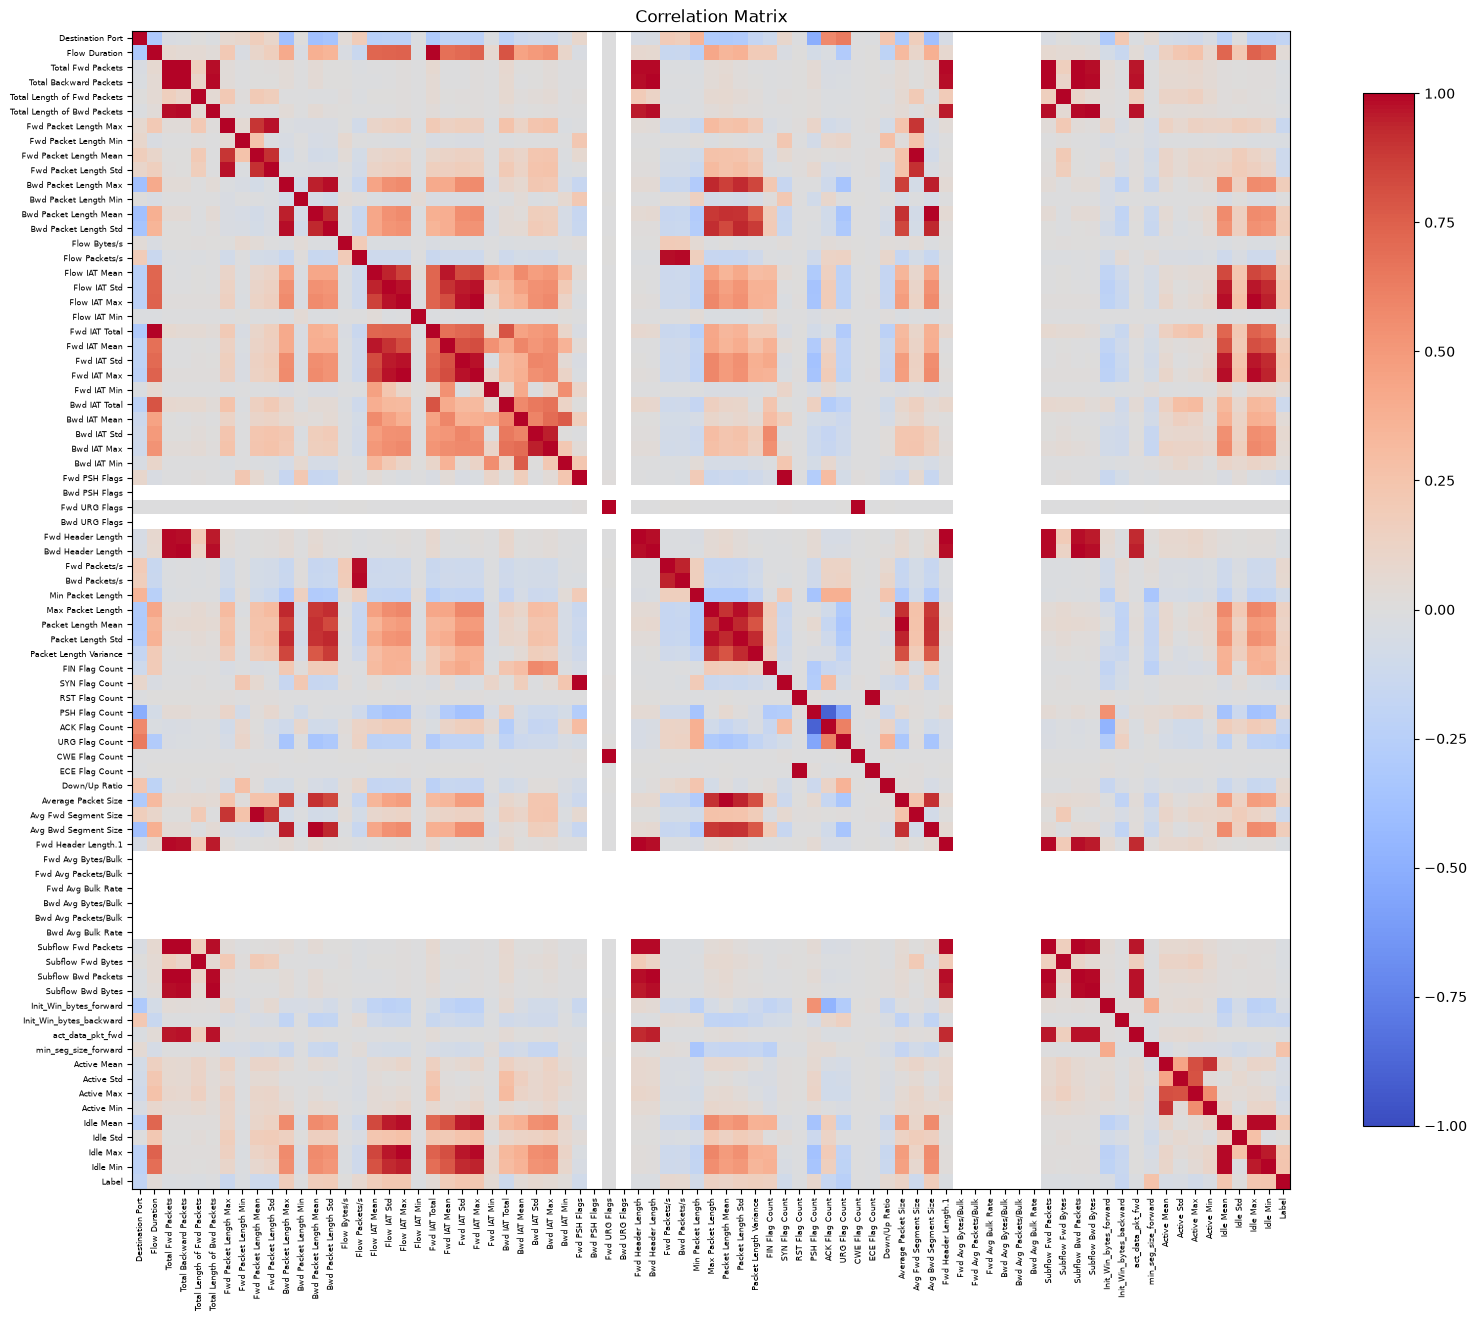

In [40]:
# Draw heatmaps

# Correlation
corr = ransomware_df.corr()

# Plot
fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticklabels(corr.columns, fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

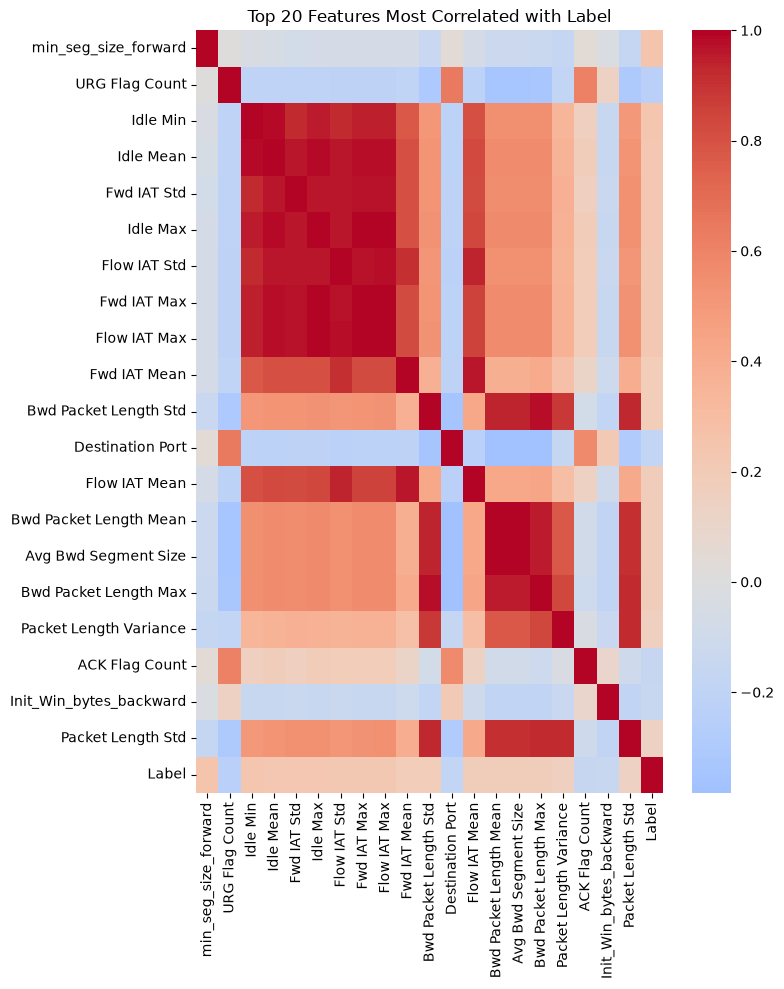

min_seg_size_forward       0.252715
URG Flag Count            -0.240664
Idle Min                   0.234699
Idle Mean                  0.232847
Fwd IAT Std                0.229975
Idle Max                   0.228191
Flow IAT Std               0.226046
Fwd IAT Max                0.224116
Flow IAT Max               0.221947
Fwd IAT Mean               0.186364
Bwd Packet Length Std      0.182767
Destination Port          -0.179736
Flow IAT Mean              0.178303
Bwd Packet Length Mean     0.177611
Avg Bwd Segment Size       0.177611
Bwd Packet Length Max      0.175375
Packet Length Variance     0.158704
ACK Flag Count            -0.156081
Init_Win_bytes_backward   -0.153515
Packet Length Std          0.144530
Name: Label, dtype: float64

In [41]:
# More readable: top features most correlated with Label
label_corr = corr['Label'].drop('Label').sort_values(key=lambda s: s.abs(), ascending=False)
top_n = 20
top_features = label_corr.head(top_n).index.tolist()

plt.figure(figsize=(8, 10))
sns.heatmap(ransomware_df[top_features + ['Label']].corr(), cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True)
plt.title(f"Top {top_n} Features Most Correlated with Label")
plt.tight_layout()
plt.show()

label_corr.head(top_n)

### Principal Component Analysis (PCA)

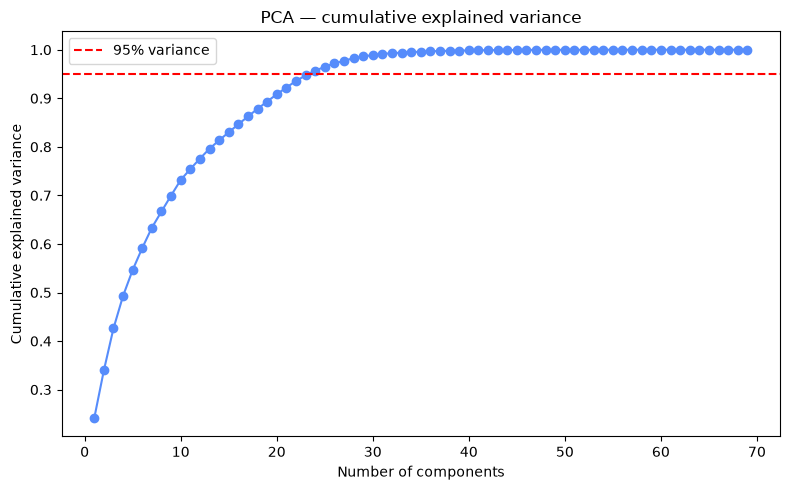

Components needed to explain 95% variance: 24 / 69


In [42]:
# Principal Component Analysis
X = intrusion_df.drop(columns=['Label'])
y = intrusion_df['Label']

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cumulative) + 1), cumulative, marker='o')
ax.axhline(0.95, color='red', linestyle='--', label='95% variance')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — cumulative explained variance')
ax.legend()
plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95) + 1)
print(f"Components needed to explain 95% variance: {n_components_95} / {X.shape[1]}")

### Bubbleplots

In [43]:
# Setup: Using the first 3 principal components as plot axes (PC1/PC2/PC3), with bubble size mapped to a chosen raw feature and color mapped to `Label`.
pcs = pca.transform(X_scaled)
pc_df = pd.DataFrame(pcs[:, :3], columns=['PC1', 'PC2', 'PC3'], index=X.index)

def scaled_size(series, low=20, high=800):
    s = (series - series.min()) / (series.max() - series.min())
    return s * (high - low) + low

label_names = {
    0: 'BENIGN',
    1: 'Bot',
    2: 'DDoS',
    3: 'DoS GoldenEye',
    4: 'DoS Hulk',
    5: 'DoS Slowhttptest',
    6: 'DoS slowloris',
    7: 'FTP-Patator',
    8: 'Heartbleed',
    9: 'Infiltration',
    10: 'PortScan',
    11: 'SSH-Patator',
    12: 'Web Attack - Brute Force',
    13: 'Web Attack - Sql Injection',
    14: 'Web Attack - XSS',
}

# 15 classes won't fit matplotlib's tab: palette (only 10 named colors), so pull a
# 15-color palette from a qualitative colormap instead.
palette = plt.cm.tab20(np.linspace(0, 1, len(label_names)))
label_colors = {i: palette[i] for i in label_names}

In [44]:
# Bubbleplot function
def bubble_plot(x_col, y_col, size_col, title, filename):
    fig, ax = plt.subplots(figsize=(9, 7))
    sizes = scaled_size(X[size_col])
    for lbl, color in label_colors.items():
        mask = (y == lbl)
        ax.scatter(pc_df.loc[mask, x_col], pc_df.loc[mask, y_col],
                   s=sizes[mask], c=color, alpha=0.5, edgecolors='k', linewidths=0.3,
                   label=label_names[lbl])
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{title}\n(bubble size = {size_col})")
    ax.legend(title='Label', markerscale=0.5)
    plt.tight_layout()
    plt.show()

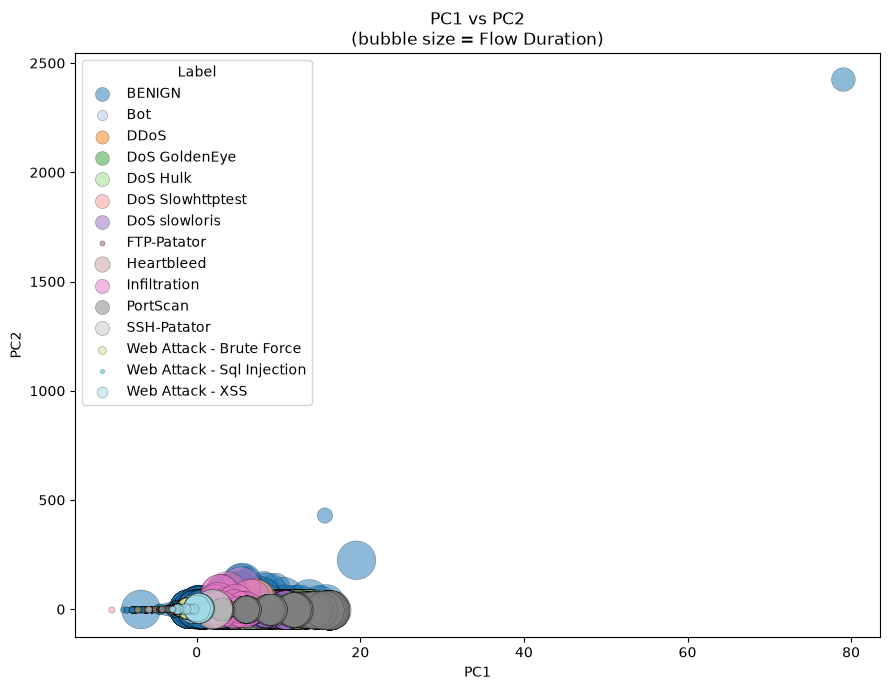

In [45]:
# Bubbleplot for Flow Duration
bubble_plot('PC1', 'PC2', 'Flow Duration', 'PC1 vs PC2', 'intrusion_bubble_pc1_pc2_flowduration.png')

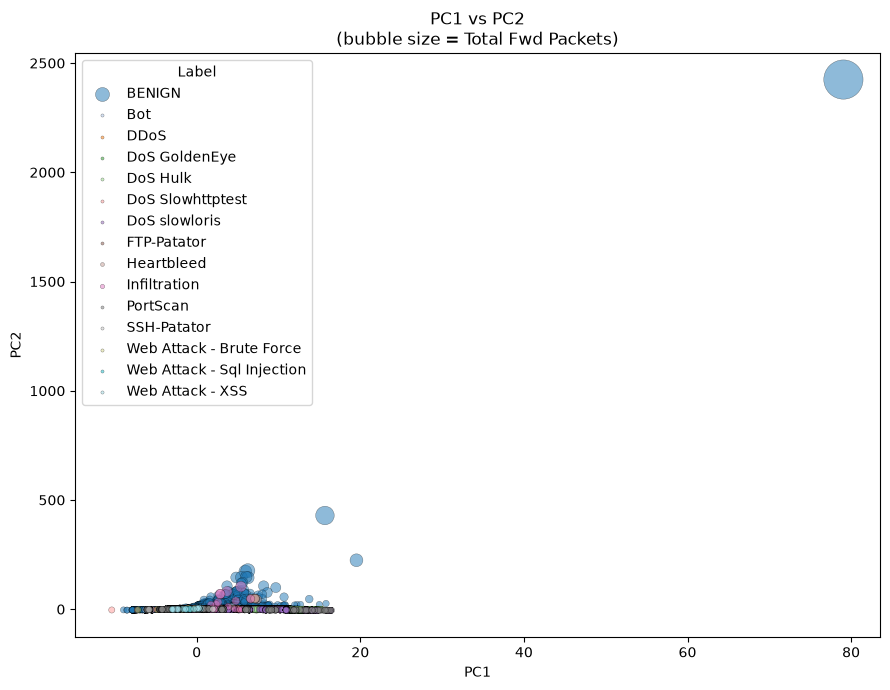

In [46]:
# Bubbleplot for Total Fwd Packets
bubble_plot('PC1', 'PC2', 'Total Fwd Packets', 'PC1 vs PC2', 'intrusion_bubble_pc1_pc2_totalfwdpackets.png')

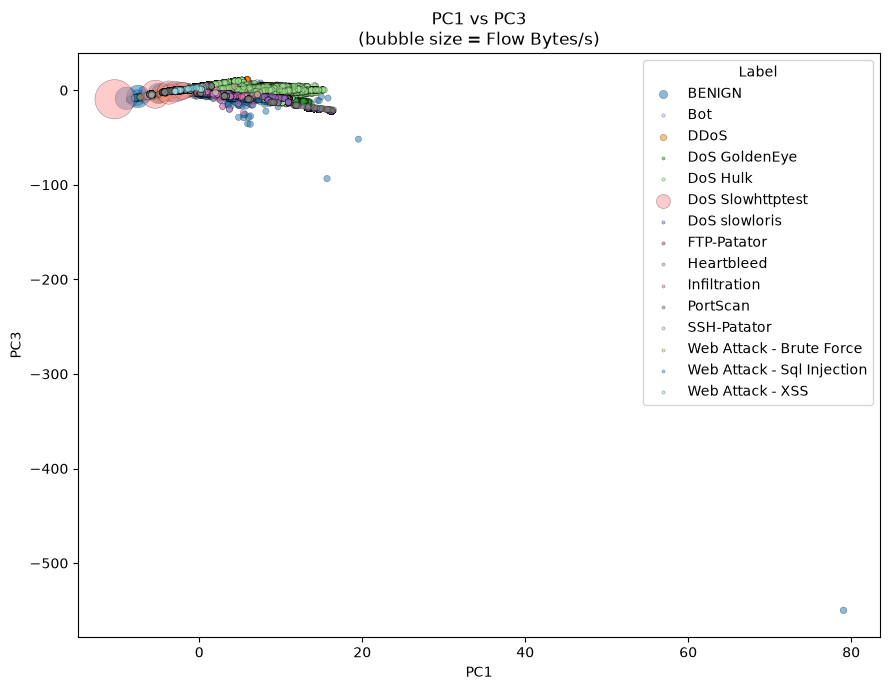

In [47]:
# Bubbleplot for Flow Bytes/s
bubble_plot('PC1', 'PC3', 'Flow Bytes/s', 'PC1 vs PC3', 'intrusion_bubble_pc1_pc3_flowbytespersec.png')

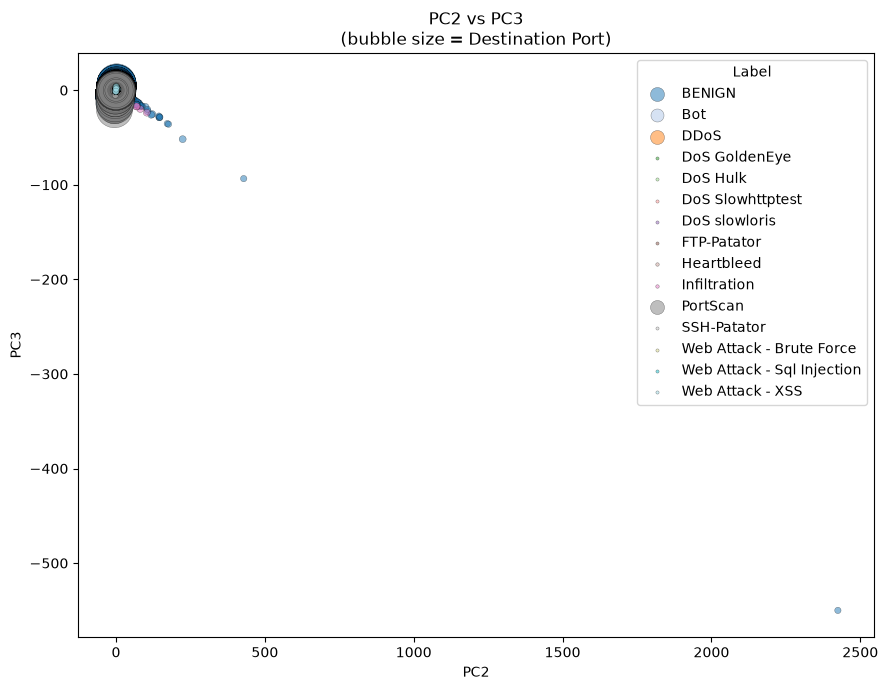

In [48]:
# Bubbleplot for Destination Port
bubble_plot('PC2', 'PC3', 'Destination Port', 'PC2 vs PC3', 'intrusion_bubble_pc2_pc3_destinationport.png')

### Regression

In [49]:
# Regression

# Training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (1041847, 69) Test shape: (260462, 69)


#### Linear Regression

In [50]:
# Linear Regression Analysis

# Calculate the R^2 and RMSE
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)

print(f"R^2: {r2_score(y_test, y_pred_lin):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_lin) ** 0.5:.4f}")

y_pred_lin_class = (y_pred_lin >= 0.5).astype(int)
print(f"Accuracy (0.5 threshold on linear output): {accuracy_score(y_test, y_pred_lin_class):.4f}")

R^2: 0.4477
RMSE: 2.1155
Accuracy (0.5 threshold on linear output): 0.3090


In [51]:
# Create Coefficient DataFrame & print
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lin_reg.coef_
}).sort_values('coefficient', key=abs, ascending=False)

coef_df.head(15)

,feature,coefficient
40,Packet Length Mean,-7.374090
50,Average Packet Size,6.465305
67,Idle Max,5.774326
39,Max Packet Length,3.392586
3,Total Backward Packets,2.928311
68,Idle Min,-2.862901
18,Flow IAT Max,-2.508957
10,Bwd Packet Length Max,-2.134085
35,Bwd Header Length,-2.026096
41,Packet Length Std,-1.918189


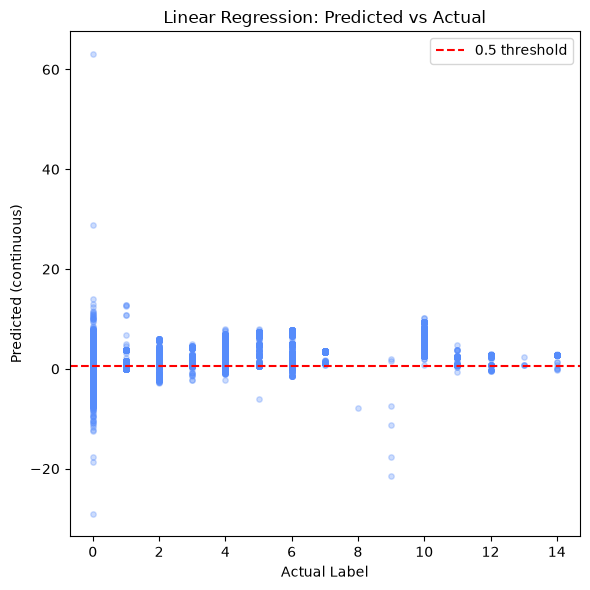

In [52]:
# Plot the Regression
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_lin, alpha=0.3, s=15)
ax.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
ax.set_xlabel('Actual Label')
ax.set_ylabel('Predicted (continuous)')
ax.set_title('Linear Regression: Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.show()

#### Logistic Regression

In [54]:
# Logistic Regression

# Setup
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)  # full (n_samples, 15) probability matrix

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"ROC-AUC (macro, OvR): {roc_auc_score(y_test, y_proba_log, multi_class='ovr', average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_log, target_names=[
    'BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest',
    'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan',
    'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS'
]))

Accuracy: 0.9929
ROC-AUC (macro, OvR): 0.9964

                            precision    recall  f1-score   support

                    BENIGN       0.99      1.00      1.00    188006
                       Bot       1.00      0.02      0.04       390
                      DDoS       1.00      1.00      1.00     16294
             DoS GoldenEye       0.98      0.92      0.95      1542
                  DoS Hulk       1.00      0.99      1.00     32692
          DoS Slowhttptest       0.93      0.73      0.82       417
             DoS slowloris       0.90      0.86      0.88       749
               FTP-Patator       0.97      1.00      0.98      1173
                Heartbleed       1.00      1.00      1.00         1
              Infiltration       0.57      0.67      0.62         6
                  PortScan       0.98      1.00      0.99     18126
               SSH-Patator       0.99      0.92      0.96       641
  Web Attack - Brute Force       0.79      0.04      0.07       294


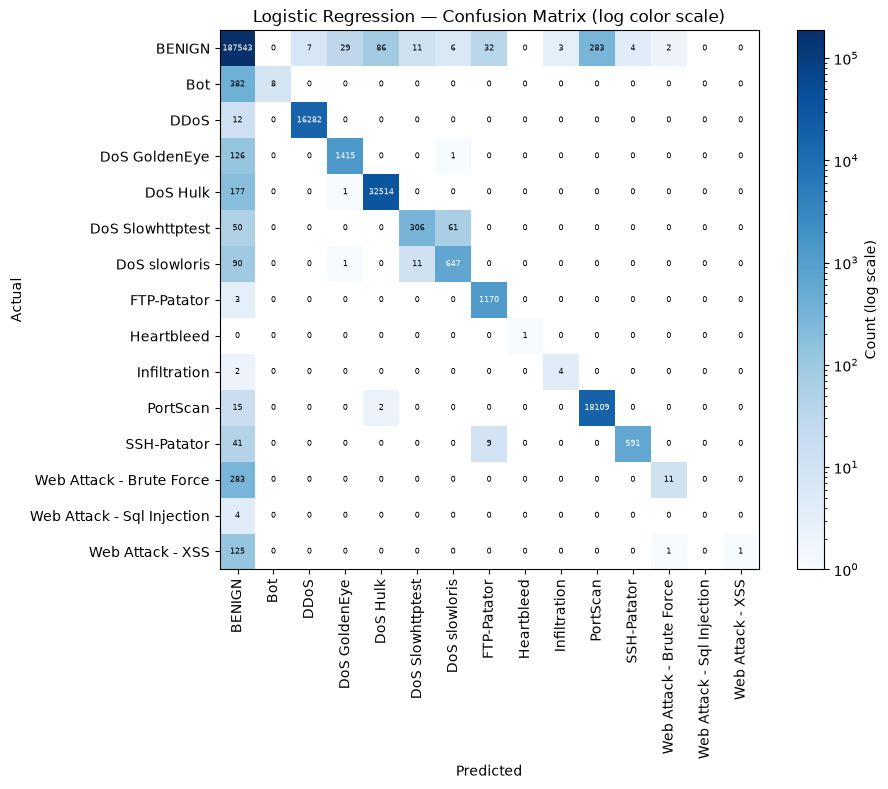

In [55]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_log)
n_classes = len(label_names)
class_names = [label_names[i] for i in range(n_classes)]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues', norm=LogNorm(vmin=1, vmax=cm.max()))

for i in range(n_classes):
    for j in range(n_classes):
        val = cm[i, j]
        # zero cells fall outside LogNorm's range and render as background, so just use black text there
        text_color = 'black' if val == 0 else ('white' if im.norm(val) > 0.5 else 'black')
        ax.text(j, i, val, ha='center', va='center', fontsize=6, color=text_color)

ax.set_xticks(range(n_classes)); ax.set_xticklabels(class_names, rotation=90)
ax.set_yticks(range(n_classes)); ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression — Confusion Matrix (log color scale)')
fig.colorbar(im, ax=ax, label='Count (log scale)')
plt.tight_layout()
plt.show()

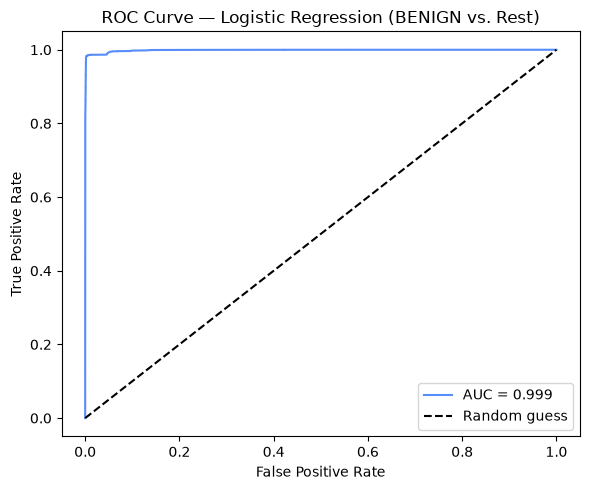

In [56]:
# ROC Curve

# BENIGN vs. Rest
benign_idx = 0  # index of 'BENIGN' in label_names / label_to_int

y_test_binary = (y_test != benign_idx).astype(int)                        # 1 = any attack, 0 = BENIGN
y_score_binary = 1 - log_reg.predict_proba(X_test_scaled)[:, benign_idx]  # P(not BENIGN)

fpr, tpr, _ = roc_curve(y_test_binary, y_score_binary)
auc = roc_auc_score(y_test_binary, y_score_binary)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression (BENIGN vs. Rest)')
ax.legend()
plt.tight_layout()
plt.show()

## Dataset 3: Misinformation

### Setup

In [87]:
# Load the dataset
misinformation_df = pd.read_csv("misinformation.csv", encoding="latin1", dtype=str)

# Drop unnamed index columns and clean up column names
misinformation_df = misinformation_df.loc[:, ~misinformation_df.columns.str.contains('^Unnamed')]
misinformation_df.columns = misinformation_df.columns.str.strip()

print(misinformation_df.shape)

(72134, 3)


In [88]:
# Print the dataset
misinformation_df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [89]:
# Normalize the Label column

# Where 1 = real, 0 = fake. Since they're already 0, 1, verify they are ints. 
print("Unique label values:", sorted(misinformation_df['label'].unique()))

misinformation_df['label'] = misinformation_df['label'].astype(int)
misinformation_df['label'].value_counts()

Unique label values: ['0', '1']


label
1    37106
0    35028
Name: count, dtype: int64

In [90]:
# Drop duplicate rows
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 8456 duplicate rows -> 63678 rows remaining


In [91]:
# Drop null & NaN values
before = len(misinformation_df)
misinformation_df = misinformation_df.dropna()
print(f"Dropped {before - len(misinformation_df)} rows with null/NaN values -> {len(misinformation_df)} rows remaining")

Dropped 557 rows with null/NaN values -> 63121 rows remaining


In [92]:
# Create numerical columns
def add_text_features(df, col, prefix):
    text = df[col].astype(str)
    words = text.str.split()

    df[f'{prefix}_word_count'] = words.str.len()
    df[f'{prefix}_char_count'] = text.str.len()
    df[f'{prefix}_avg_word_length'] = (
        df[f'{prefix}_char_count'] / df[f'{prefix}_word_count'].replace(0, np.nan)
    ).fillna(0)
    df[f'{prefix}_exclamation_count'] = text.str.count('!')
    df[f'{prefix}_question_count'] = text.str.count(r'\?')
    df[f'{prefix}_digit_count'] = text.str.count(r'\d')
    df[f'{prefix}_uppercase_word_count'] = words.apply(
        lambda ws: sum(1 for w in ws if w.isupper() and len(w) > 1)
    )
    return df

misinformation_df = add_text_features(misinformation_df, 'title', 'title')
misinformation_df = add_text_features(misinformation_df, 'text', 'text')

misinformation_df.filter(like='_count').head()

,title_word_count,title_char_count,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,18,130,0,0,6,7,871,5049,2,7,30,6
2,18,145,1,0,0,9,34,216,0,0,0,0
3,16,105,0,0,4,0,1321,8120,0,1,34,7
4,16,101,0,0,1,1,329,1932,0,0,70,16
5,13,78,1,0,0,1,244,1530,1,0,0,13


In [94]:
# Drop negative values
before = len(misinformation_df)
numeric_cols = misinformation_df.select_dtypes(include=[np.number]).columns
negative_mask = (misinformation_df[numeric_cols] < 0).any(axis=1)
misinformation_df = misinformation_df[~negative_mask]
print(f"Dropped {before - len(misinformation_df)} rows containing negative values -> {len(misinformation_df)} rows remaining")

Dropped 0 rows containing negative values -> 63121 rows remaining


In [95]:
# Drop non-numerical columns
non_numeric_cols = misinformation_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

misinformation_df = misinformation_df.drop(columns=non_numeric_cols)
print(misinformation_df.shape)

Dropping non-numeric columns: ['title', 'text']
(63121, 15)


In [96]:
# Drop perfectly correlated columns
corr_matrix = misinformation_df.drop(columns=['label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

misinformation_df = misinformation_df.drop(columns=perfectly_correlated)
print(misinformation_df.shape)

Dropping 0 columns with ~1.00 correlation to an earlier column:
[]
(63121, 15)


In [97]:
# Drop duplicate rows (post feature engineering)
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 48 duplicate rows -> 63073 rows remaining


In [98]:
# Print clean DataFrame
misinformation_df.head()

,label,title_word_count,title_char_count,title_avg_word_length,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_avg_word_length,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,1,18,130,7.222222,0,0,6,7,871,5049,5.796785,2,7,30,6
2,1,18,145,8.055556,1,0,0,9,34,216,6.352941,0,0,0,0
3,0,16,105,6.562500,0,0,4,0,1321,8120,6.146858,0,1,34,7
4,1,16,101,6.312500,0,0,1,1,329,1932,5.872340,0,0,70,16
5,1,13,78,6.000000,1,0,0,1,244,1530,6.270492,1,0,0,13


In [99]:
# Sanity check
print("Any nulls left:", misinformation_df.isnull().values.any())
print("Any negatives left:", (misinformation_df < 0).values.any())
print("Any duplicate rows left:", misinformation_df.duplicated().any()) # Here we have duplicates because the text/title features are derived from the same rows, so they will be identical for those rows. This is expected and not a problem.
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in misinformation_df.dtypes))
print("\nFinal shape:", misinformation_df.shape)
print("\nLabel counts:")
print(misinformation_df['label'].value_counts())

Any nulls left: False
Any negatives left: False
Any duplicate rows left: False
All columns numeric: True

Final shape: (63073, 15)

Label counts:
label
0    34780
1    28293
Name: count, dtype: int64


In [100]:
# Export cleaned data to CSV
misinformation_df.to_csv("misinformation_clean.csv", index=False)
print("Saved misinformation_clean.csv")

Saved misinformation_clean.csv


### Heatmaps

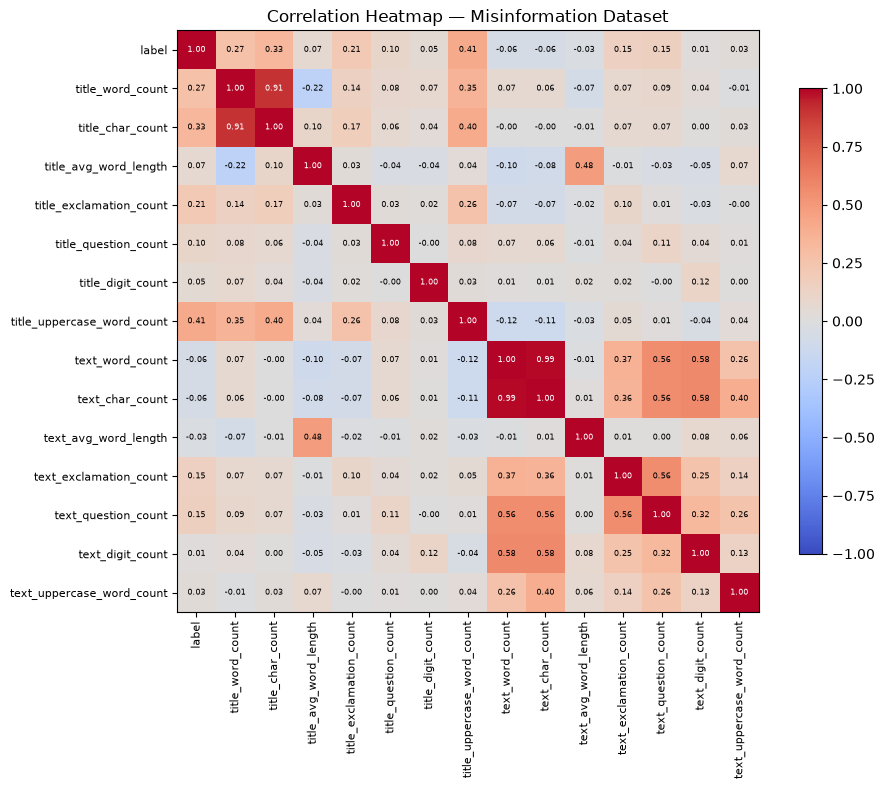

In [101]:
# Draw Heatmaps

# Correlation
corr = misinformation_df.corr()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)

# annotate cells with the correlation value (dataset is small enough to be readable)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=6,
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation Heatmap — Misinformation Dataset")
plt.tight_layout()
plt.show()

### Principal Component Analysis (PCA)

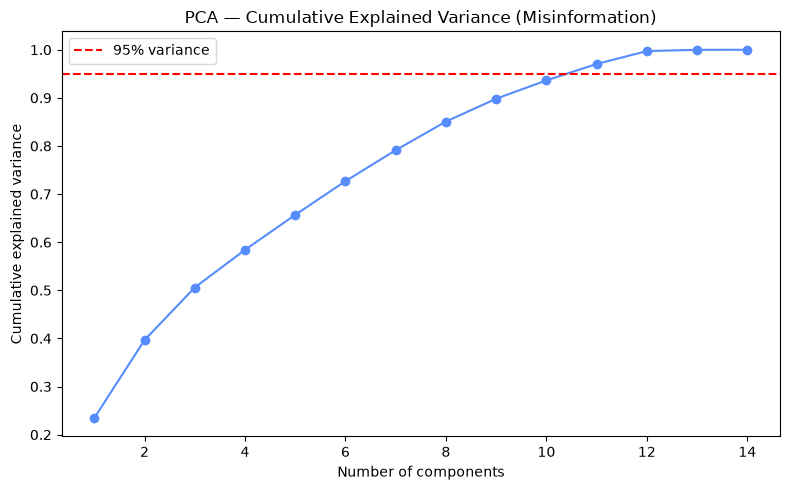

Components needed to explain 95% variance: 11 / 14


In [102]:
# Principal Component Analysis
X = misinformation_df.drop(columns=['label'])
y = misinformation_df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cumulative) + 1), cumulative, marker='o')
ax.axhline(0.95, color='red', linestyle='--', label='95% variance')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — Cumulative Explained Variance (Misinformation)')
ax.legend()
plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95) + 1)
print(f"Components needed to explain 95% variance: {n_components_95} / {X.shape[1]}")

### Bubbleplots

In [107]:
# Draw bubbleplots

# Setup: Using the first 3 principal components as plot axes (PC1/PC2/PC3), with bubble size mapped to a chosen raw feature and color mapped to `Label` (fake vs. real).
pcs = pca.transform(X_scaled)
pc_df = pd.DataFrame(pcs[:, :3], columns=['PC1', 'PC2', 'PC3'], index=X.index)

def scaled_size(series, low=20, high=800):
    s = (series - series.min()) / (series.max() - series.min())
    return s * (high - low) + low

label_names = {0: 'FAKE', 1: 'REAL'}
label_colors = {0: 'tab:red', 1: 'tab:blue'}

In [108]:
# Bubbleplot function
def bubble_plot(x_col, y_col, size_col, title, filename):
    fig, ax = plt.subplots(figsize=(9, 7))
    sizes = scaled_size(X[size_col])
    for lbl, color in label_colors.items():
        mask = (y == lbl)
        ax.scatter(pc_df.loc[mask, x_col], pc_df.loc[mask, y_col],
                   s=sizes[mask], c=color, alpha=0.5, edgecolors='k', linewidths=0.3,
                   label=label_names[lbl])
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{title}\n(bubble size = {size_col})")
    ax.legend(title='Label', markerscale=0.5)
    plt.tight_layout()
    plt.show()

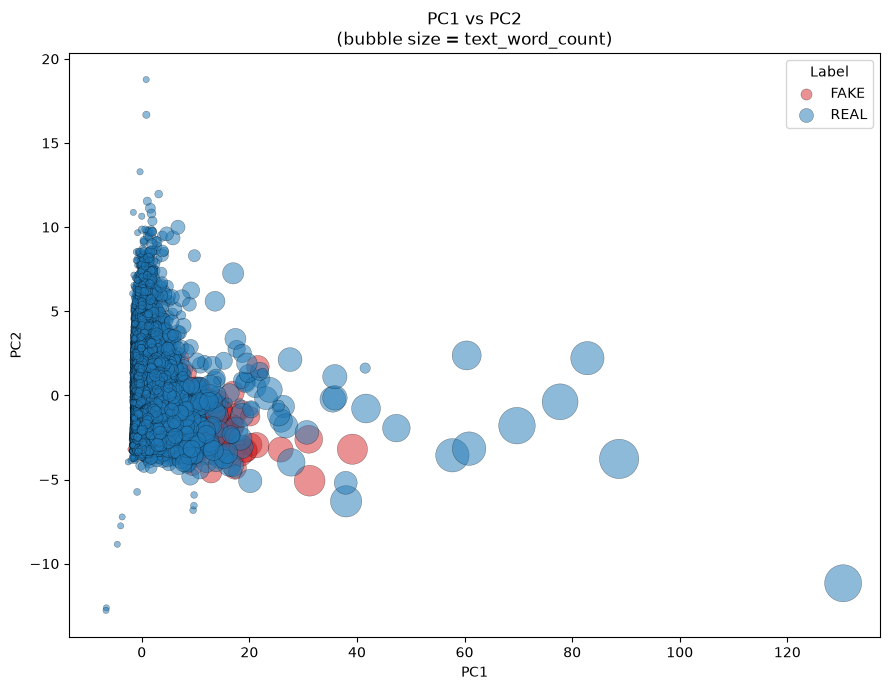

In [109]:
# Bubbleplot for Text Word Count
bubble_plot('PC1', 'PC2', 'text_word_count', 'PC1 vs PC2', 'misinformation_bubble_pc1_pc2_textwordcount.png')

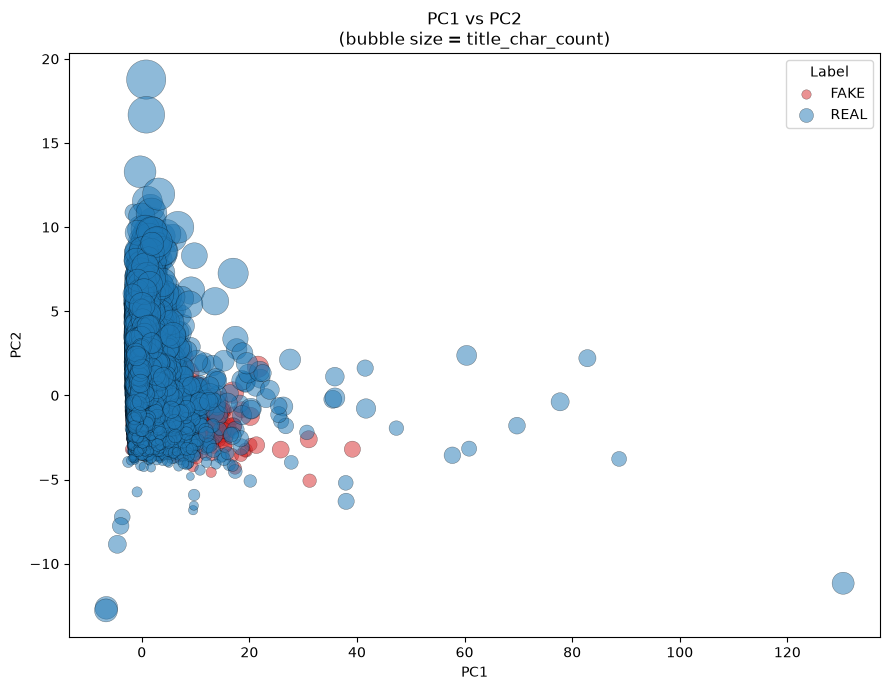

In [110]:
# Bubbleplot for Title Char Count
bubble_plot('PC1', 'PC2', 'title_char_count', 'PC1 vs PC2', 'misinformation_bubble_pc1_pc2_titlecharcount.png')

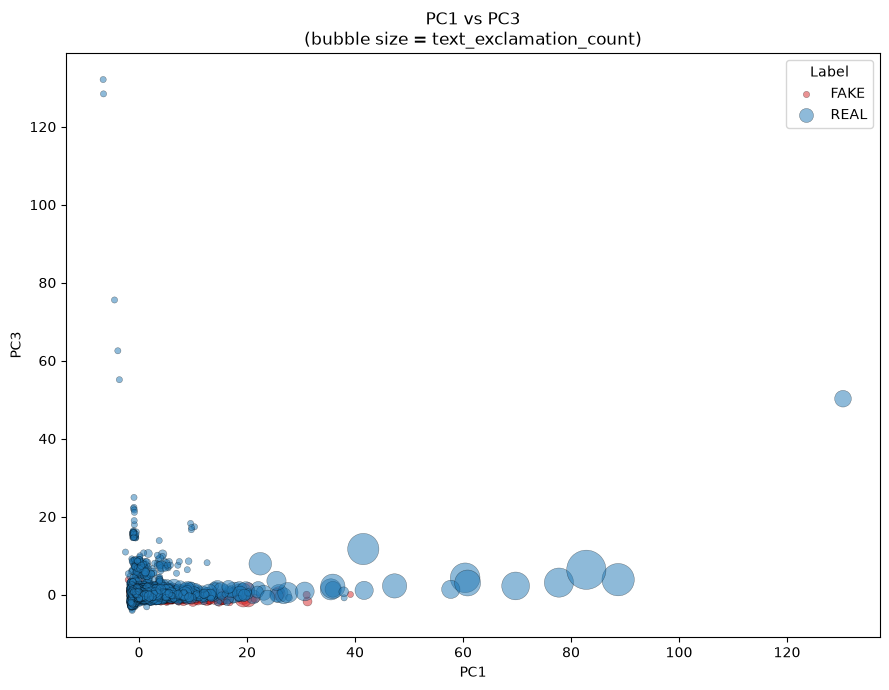

In [111]:
# Bubbleplot for Text Exclamation Count
bubble_plot('PC1', 'PC3', 'text_exclamation_count', 'PC1 vs PC3', 'misinformation_bubble_pc1_pc3_exclamation.png')

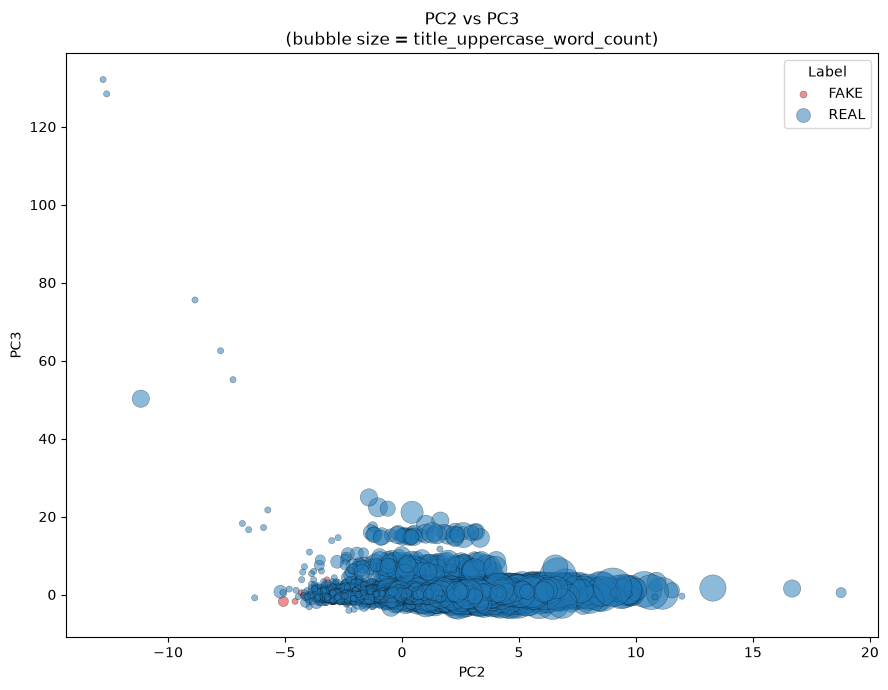

In [112]:
# Bubbleplot for Title Uppercase Word Count
bubble_plot('PC2', 'PC3', 'title_uppercase_word_count', 'PC2 vs PC3', 'misinformation_bubble_pc2_pc3_uppercase.png')

### Regression Analysis

In [113]:
# Regression

# Training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (50458, 14) Test shape: (12615, 14)


#### Linear Regression

In [114]:
# Linear Regression Analysis

# Calculate teh R^2 and RMSE
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)

print(f"R^2: {r2_score(y_test, y_pred_lin):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_lin) ** 0.5:.4f}")

y_pred_lin_class = (y_pred_lin >= 0.5).astype(int)
print(f"Accuracy (0.5 threshold on linear output): {accuracy_score(y_test, y_pred_lin_class):.4f}")

R^2: 0.2662
RMSE: 0.4260
Accuracy (0.5 threshold on linear output): 0.7698


In [115]:
# Create Coefficient DataFrame & print
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lin_reg.coef_
}).sort_values('coefficient', key=abs, ascending=False)

coef_df.head(15)

,feature,coefficient
8,text_char_count,-0.196444
6,title_uppercase_word_count,0.142908
1,title_char_count,0.137344
7,text_word_count,0.107960
11,text_question_count,0.082704
0,title_word_count,-0.056198
3,title_exclamation_count,0.043119
12,text_digit_count,0.028593
4,title_question_count,0.027402
10,text_exclamation_count,0.026943


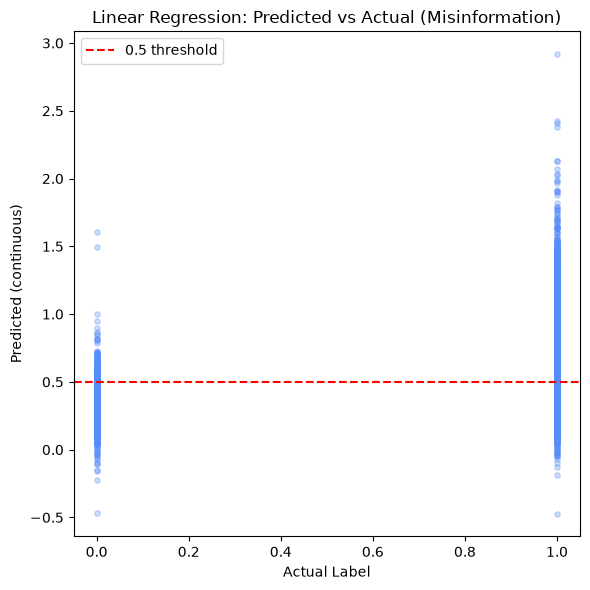

In [116]:
# Plot the Regression
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_lin, alpha=0.3, s=15)
ax.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
ax.set_xlabel('Actual Label')
ax.set_ylabel('Predicted (continuous)')
ax.set_title('Linear Regression: Predicted vs Actual (Misinformation)')
ax.legend()
plt.tight_layout()
plt.show()

#### Logistic Regression

In [117]:
# Logistic Regression

# Setup
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_log):.4f}")
print()
print(classification_report(y_test, y_pred_log, target_names=['FAKE', 'REAL']))

Accuracy: 0.7829
ROC-AUC: 0.8252

              precision    recall  f1-score   support

        FAKE       0.75      0.91      0.82      6956
        REAL       0.85      0.63      0.72      5659

    accuracy                           0.78     12615
   macro avg       0.80      0.77      0.77     12615
weighted avg       0.79      0.78      0.78     12615



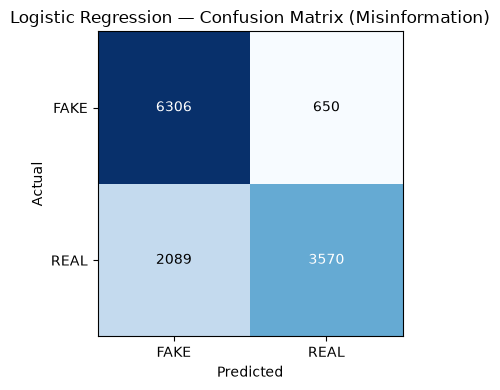

In [118]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['FAKE', 'REAL'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['FAKE', 'REAL'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression — Confusion Matrix (Misinformation)')
plt.tight_layout()
plt.show()

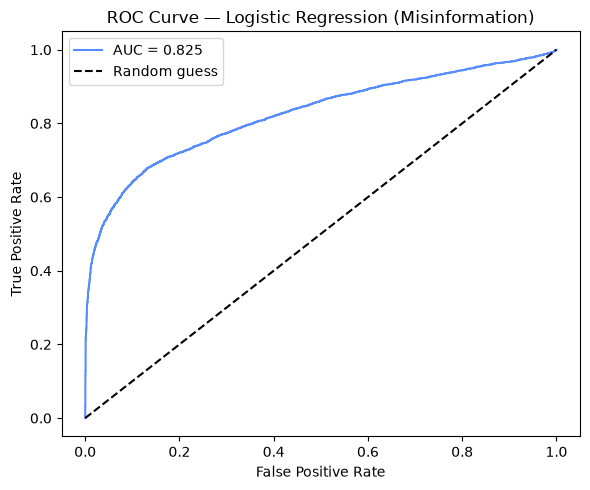

In [119]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_log)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba_log):.3f}")
ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression (Misinformation)')
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion

Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

**Ransomware / malware traffic dataset:**
This is still CICFlowMeter-style network flow data (packet counts, byte counts, inter-arrival times, flags) — the standard format for traffic-based malware detection — so the shape and features are unsurprising. Bringing in the additional benign CSVs worked: after cleaning, the class split is now 7,865 ransomware (label 1) vs. 6,298 benign (label 0), a reasonable ~55/45 split instead of the earlier ~90/10 imbalance. But that fix revealed something important — model performance actually got *worse*, not better. With the classes balanced, logistic regression drops to 59.3% accuracy and a 0.655 ROC-AUC (recall of only 44% on BENIGN, 72% on RANSOMWARE_WANNALOCKER), compared to the 90%+ accuracy seen when the data were imbalanced. That earlier number was mostly a class-imbalance artifact — the model was largely just predicting the majority class and getting credit for it. The honest read: the data are clean and usable, but these 72 flow-level features only weakly separate this specific ransomware family from benign traffic on their own. Additional features, more ransomware samples, or a non-linear classifier (e.g. random forest) would likely be needed before trusting this for real detection. Separately, the earlier concern about `Init_Win_bytes_backward`'s -1 sentinel value being wrongly treated as invalid has been fixed by excluding that column from the negative-value filter, so the 4,068 rows dropped for negative values now reflect genuinely out-of-range values elsewhere, not discarded legitimate flows.

**Intrusion dataset:**
Same CICFlowMeter schema as ransomware, so no surprises in shape. The pipeline now runs cleanly end-to-end: 2,830,743 raw rows → 2,522,362 after dedup → 2,520,798 after dropping 1,564 null/NaN rows (now correctly including the former `Infinity` values in `Flow Bytes/s`/`Flow Packets/s`, since those are converted to NaN right after the numeric conversion) → 1,302,309 after the negative-value filter → same 1,302,309 rows × 70 columns after dropping the 9 perfectly-correlated columns. One thing still worth fixing, though: that negative-value filter drops 1,218,489 rows, and the overwhelming majority of that is the same `-1` "no data" sentinel issue already fixed for ransomware — `Init_Win_bytes_forward`/`Init_Win_bytes_backward` — just not yet excluded here. Model performance turned out to be genuinely strong, and better than the imbalance would suggest: Logistic Regression hits 99.29% accuracy and a macro OvR AUC of 0.996, and — unlike a typical imbalance story — that holds up per-class for anything with a reasonable sample count: DDoS, DoS Hulk, PortScan, and FTP-Patator all reach recall ≥ 0.99, DoS GoldenEye and SSH-Patator ≥ 0.92, and even 6-sample Infiltration reaches 0.67 recall. The real weak spot is a small handful of very sparse, low-signal classes — Bot (recall 0.02), Web Attack - Brute Force (0.04), Web Attack - XSS (0.01), and the 21-sample Web Attack - Sql Injection (0.00) — which the model essentially never identifies; that's why macro-avg F1 (0.69) sits well below weighted-avg F1 (0.99), a gap driven by these four classes specifically rather than a broad imbalance problem. The BENIGN-vs-Rest framing is cleaner still (AUC 0.999). Honest read: the data are clean and usable, and once the sentinel-column fix is applied this is actually an easier classification problem than ransomware was — the one real limitation is the handful of severely under-represented attack types, which would need oversampling, class weighting, or dedicated detection before trusting the model on them specifically.

**Misinformation dataset:**
The dataset itself remains well-behaved and usable: 63,073 cleaned rows with a reasonable 55/45 fake-real split (34,780 vs. 28,293), no need to source new data. The counter-intuitive result from earlier analysis still holds: `title_uppercase_word_count` correlates +0.41 with label (1 = real), meaning *real* articles use more all-caps words in their titles than fake ones do (most likely acronyms like "U.S." or "FBI" rather than sensational emphasis) — so the naive "sensational language = fake" story doesn't hold cleanly here. Collapsing full articles down to 14 count-based features also means many distinct articles land on identical feature vectors, which is why a duplicate-removal pass after feature engineering was needed (48 rows dropped). 78.3% logistic regression accuracy (ROC-AUC 0.825) is a reasonable ceiling for this coarse, count-based feature set — not a sign of bad data.

Do you see any outliers? (Data points that are far from the rest of the data).

**Ransomware / malware traffic dataset:**
Yes, clearly visible in the PC1/PC2 bubble plot. The overwhelming majority of flows cluster tightly within roughly ±10 of the origin, but a handful sit far outside that — one point near (PC1≈44, PC2≈−31), another around (PC1≈30, PC2≈−14 to −20), and several more scattered beyond PC1=15. This is consistent with a small number of unusually large or long-lived flows (heavy-tailed byte/packet distributions are normal for network traffic), but they're extreme enough that they could dominate a linear model's coefficients if left untreated — worth considering robust scaling or winsorizing before regression.

**Intrusion dataset:**
Yes, and more extreme than either of the other two datasets — one single point dominates almost the entire PCA structure. Across all 1.3M cleaned flows, one BENIGN-labeled row sits at PC2≈2,424, roughly 6x further out than the next most extreme point (PC2≈429), and the same row sits at PC3≈−550 versus a next-most-extreme value of only ≈−93. Everything else clusters within roughly ±10 on PC1, the same heavy-tailed pattern seen in the ransomware set (unsurprising given the shared CICFlowMeter schema). A single point this dominant is worth inspecting directly — it's extreme enough to single-handedly skew variance calculations and any linear model's coefficients, and is a strong candidate for winsorizing or removal before it's trusted in PCA-based plots or regression.

**Misinformation dataset:**
Yes, and visually even more pronounced than the ransomware set. In the PC2/PC3 bubble plot, the bulk of articles cluster near PC3≈0, but a few real-labeled articles sit dramatically apart — as high as PC3≈130, 128, 76, 63, and 55. These are almost certainly very long articles, ALL-CAPS press releases, or scraped pages with unusual formatting, and they're far enough from the rest of the distribution to be worth inspecting individually before trusting a linear model built on this feature set.

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

**Ransomware / malware dataset:**
Not really. PC1 explains only about 22–23% of variance, PC1+PC2 together only about 35–36%, and it takes 24 of the 72 features to reach 95% cumulative variance. A 1–2 component summary would lose most of the signal here — even after removing the redundant/duplicate columns (see below), this dataset's 72 remaining features still capture genuinely distinct aspects of a flow (timing, size, flags) rather than a few redundant measurements in disguise.

**Intrusion dataset:**
It's very similar to the malware/ransomware dataset, and the numbers land almost identically. PC1 explains about 24% of variance, PC1+PC2 about 34%, and it takes 24 of the 69 remaining features to reach 95% cumulative variance — essentially the same profile as the ransomware dataset, which makes sense since both share the same CICFlowMeter feature schema. No meaningful low-dimensional shortcut here either; the timing, size, and flag-based features are each capturing something the others aren't.

**Misinformation dataset:**
Also not much reduction available. PC1 explains about 23% of variance, PC1+PC2 about 40%, and it takes 11 of the 14 features to reach 95% cumulative variance. These engineered features are already fairly non-redundant — word count, character count, punctuation, and capitalization each capture a different aspect of the text — so there isn't much of a low-dimensional shortcut here either.

Try using your correlation information from previous weeks to help choose features for linear regression.

**Ransomware / malware dataset:**
Yes — this is exactly what the "Drop perfectly correlated columns" step does, right before the sanity check. Using the correlation matrix, any column with a correlation of 1.00 to an earlier-appearing column was dropped, keeping only the first of each pair. Eight columns were removed this way:

- `Subflow Fwd Packets` (r = 1.00 with `Total Fwd Packets`, which was kept)
- `Subflow Bwd Packets` (r = 1.00 with `Total Backward Packets`, kept)
- `Subflow Fwd Bytes` (r = 1.00 with `Total Length of Fwd Packets`, kept)
- `Subflow Bwd Bytes` (r = 1.00 with `Total Length of Bwd Packets`, kept)
- `Avg Fwd Segment Size` (r = 1.00 with `Fwd Packet Length Mean`, kept)
- `Avg Bwd Segment Size` (r = 1.00 with `Bwd Packet Length Mean`, kept)
- `SYN Flag Count` (r = 1.00 with `Fwd PSH Flags`, kept)
- `Fwd Header Length.1` (r = 1.00 with `Fwd Header Length`, kept — this one is a literal duplicate column in the source CICFlowMeter CSVs, not just a statistical coincidence)

Most of these are definitional duplicates rather than coincidences: subflow byte/packet counts equal the flow totals when a flow has exactly one subflow (the CICFlowMeter default), and "average segment size" is defined identically to mean packet length. Dropping them before regression matters because perfectly collinear predictors make OLS coefficients unstable and arbitrarily split credit between the duplicate pair — keeping just one of each avoids that without losing any information.

**Intrusion dataset:**
Yes, and the result is essentially identical to the ransomware dataset — expected, since both share the same CICFlowMeter schema. The same threshold (r ≥ 0.999) drops 9 columns: the same 8 as ransomware (`Subflow Fwd Packets`, `Subflow Bwd Packets`, `Subflow Fwd Bytes`, `Subflow Bwd Bytes`, `Avg Fwd Segment Size`, `Avg Bwd Segment Size`, `SYN Flag Count`, `Fwd Header Length.1`), plus `CWE Flag Count` (r = 1.00 with `ECE Flag Count`), which didn't show up as redundant in the ransomware data but does here — likely because this dataset's attack traffic actually exercises those flags jointly in a way the ransomware/benign traffic didn't. Worth noting separately: none of the raw features correlate strongly with Label on their own here — the top one, `min_seg_size_forward`, only reaches r ≈ 0.25 (compare to misinformation's `title_uppercase_word_count` at 0.41), and the next several (`URG Flag Count`, `Idle Min`/`Idle Mean`, `Fwd IAT Std`) all sit in the 0.22–0.24 range. That's consistent with the classification results above: separating 15 imbalanced attack types isn't something any single feature does well — it genuinely needs the full multivariate feature set.

**Misinformation dataset:**
No columns were dropped by the strict 1.00 threshold used in this notebook (correlation ≥ 0.999) — the "Drop perfectly correlated columns" cell found zero qualifying pairs. But the correlation heatmap shows two near-duplicate pairs worth flagging even though they didn't meet the cutoff: `title_word_count` vs. `title_char_count` (r = 0.91) and `text_word_count` vs. `text_char_count` (r = 0.99). These aren't coincidental either — word count and character count measure almost the same underlying thing, since longer text has both more words and more characters. A looser feature-selection threshold (e.g. 0.95 instead of 0.999) would likely drop one from each pair too. They were kept here because this notebook's redundancy check was deliberately set at the 1.00 level to catch exact/definitional duplicates, not merely highly correlated features.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

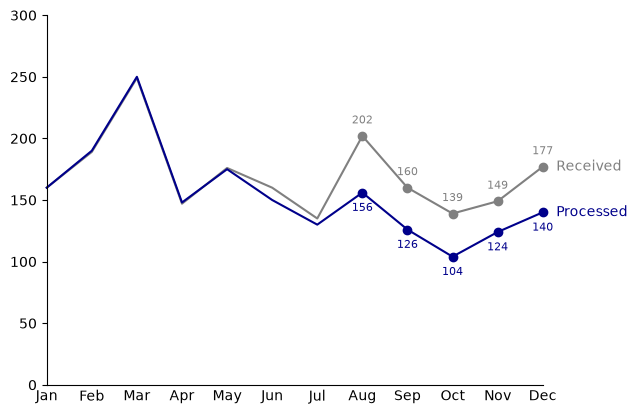

In [61]:
# Multiple Line Graph (Figure 5.8 on pg. 143)

# Data
x = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
y1 = [160, 189, 249, 147, 176, 160, 135, 202, 160, 139, 149, 177]
y2 = [160, 190, 250, 148, 175, 150, 130, 156, 126, 104, 124, 140]

# Use subplots to easily access the axes (ax) object
fig, ax = plt.subplots()

# Plotting multiple lines
line1, = plt.plot(x, y1, label='', color='gray', linestyle='-', marker='o', markevery=[7, 8, 9, 10, 11])
line2, = plt.plot(x, y2, label='', color='darkblue', linestyle='-', marker='o', markevery=[7, 8, 9, 10, 11])

# Prevent last marker from being cut in half
line1.set_clip_on(False)
line2.set_clip_on(False)

# Use the numeric index position (len(x) - 1) instead of the string name
last_index = len(x) - 1

# Force x-axis to start on y-axis and stop immediately after Dec
ax.set_xlim(left=0, right=last_index)

# Remove x-axis ticks
ax.tick_params(axis='x', length=0)

# Force y-axis to start at 0
ax.set_ylim(bottom=0)
ax.set_ylim(top=300)

ax.text(last_index + 0.3, y1[-1], 'Received', color='gray', va='center', ha='left', clip_on=False)
ax.text(last_index + 0.3, y2[-1], 'Processed', color='darkblue', va='center', ha='left', clip_on=False)

for i in range(7, len(x)):
    ax.text(i, y1[i] + 8, str(y1[i]), color='gray', ha='center', va='bottom', fontsize=8)
    ax.text(i, y2[i] - 8, str(y2[i]), color='darkblue', ha='center', va='top', fontsize=8)

# Customizations
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show plot
plt.show()